<a href="https://colab.research.google.com/github/eduardo-illueca/icg-project/blob/main/ICG_subcomplexes/RBICG_full_code_definitive_k%3D5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

This version 3 contains only the patients whose icg was recorded in baseline state (task BL)

###Data download

In [ ]:
!mkdir /content/RawData/
!wget -q https://zenodo.org/records/4725433/files/01_RawData.zip?download=1 -O /content/RawData/01_RawData.zip
!unzip -qo /content/RawData/01_RawData.zip -d /content/RawData/

!mkdir /content/FilteredData/
!wget -q https://zenodo.org/records/4725433/files/02_FilteredData.zip?download=1 -O /content/FilteredData/02_FilteredData.zip
!unzip -qo /content//FilteredData/02_FilteredData.zip -d /content//FilteredData/

!mkdir /content/Annotations/
!wget -q https://zenodo.org/records/4725433/files/03_ExpertAnnotations.zip?download=1 -O /content/Annotations/02_FilteredData.zip
!unzip -qo /content/Annotations/02_FilteredData.zip -d /content/Annotations/

###Libraries

In [ ]:
!pip install neurokit2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 696.5/696.5 kB 9.7 MB/s eta 0:00:00


In [ ]:
!pip install pyclustering

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 20.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pyclustering: filename=pyclustering-0.10.1.2-py3-none-any.whl size=2395100 sha256=e5c4752cb7bb62cf681a0c7d05a4fa0784c9313c1bfb85bbbf27408541fa092c
  Stored in directory: /root/.cache/pip/wheels/9f/99/15/e881f46a92690ae77c2e3b255b89ea45d3a867b1b6c2ab3ba9
Successfully built pyclustering


In [ ]:
!pip install tslearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 374.4/374.4 kB 7.1 MB/s eta 0:00:00


In [ ]:
!pip install kneed

In [ ]:
# ========================
# ENTORNO Y UTILIDADES
# ========================
import os
import math
import random
import json
import pickle
import ast
from pathlib import Path
from itertools import combinations
from collections import Counter, defaultdict

# ========================
# MANEJO DE DATOS
# ========================
import numpy as np
import pandas as pd
import h5py
import scipy.io as sio

# ========================
# SEÑALES Y ESTADÍSTICA
# ========================
import scipy.signal as signal
from scipy.signal import (
    butter, filtfilt, savgol_filter,
    find_peaks, argrelextrema, welch
)
from scipy import signal  # por si usas funciones como signal.resample()
from scipy.stats import (
    iqr, skew, kurtosis, entropy
)
from scipy.optimize import linear_sum_assignment
from scipy.spatial.distance import pdist, squareform
from scipy.ndimage import gaussian_filter1d

# ========================
# MACHINE LEARNING Y CLUSTERING
# ========================
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import MDS

from pyclustering.cluster.kmedoids import kmedoids
from tslearn.metrics import cdist_dtw
from scipy.spatial.distance import cdist
from kneed import KneeLocator

# ========================
# VISUALIZACIÓN
# ========================
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D
from tabulate import tabulate

# ========================
# ENTORNO INTERACTIVO / GOOGLE COLAB
# ========================
from tqdm import tqdm
import ipywidgets as widgets
from IPython.display import display, HTML
from google.colab import drive, files

# ========================
# OTROS (EJ. LIBRERÍAS EXTERNAS)
# ========================
import neurokit2 as nk


###General algorithm

We want to plot ICG spectra because we observe baseline fluctutations

Random segments were selected, and their power spectrum showed very high-frequency components that may correspond to noise rather than useful information from the ICG. For this reason, a band-pass filter from 0.5 to 20 Hz was applied to the already filtered signal, allowing only the desired frequency range to be retained.

In [ ]:
# Parámetros
fs = 250
lowcut = 0.5
highcut = 20
pre_r = int(0.15 * fs)
post_r = int(0.6 * fs)
conditions = ['BL']
num_patients = 24

# Función para filtro pasa banda Butterworth
def bandpass_filter(signal, fs, lowcut, highcut, order=4):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    filtered_signal = filtfilt(b, a, signal)
    return filtered_signal

# Lista para almacenar segmentos
all_segments = []

for patient_id in range(1, num_patients + 1):
    for condition in conditions:
        try:
            # Rutas
            path_filtered = f'/content/FilteredData/FilteredData_Subject_{patient_id}_task_{condition}.mat'
            path_annotation = f'/content/Annotations/Annotat_Subject_{patient_id}_task_{condition}.mat'

            if not os.path.exists(path_filtered):
                print(f"Archivo filtrado NO encontrado: {path_filtered}")
                continue
            if not os.path.exists(path_annotation):
                print(f"Archivo de anotaciones NO encontrado (pero no crítico): {path_annotation}")

            # Cargar ECG e ICG
            data_filtered = sio.loadmat(path_filtered)
            ecg_filtered = data_filtered['ECG'].flatten().astype(np.float64)
            icg_filtered = data_filtered['ICG'].flatten().astype(np.float64)

            # Cargar anotaciones si existen
            if os.path.exists(path_annotation):
                annotation = sio.loadmat(path_annotation)
                annotations = annotation['annotPoints']
                B, C, X, O = annotations[:, 0], annotations[:, 1], annotations[:, 2], annotations[:, 3]

            # Detección de picos R
            ecg_signals, info = nk.ecg_process(ecg_filtered, sampling_rate=fs)
            r_peaks = info["ECG_R_Peaks"]

            # Segmentación de ICG
            for i, r_peak in enumerate(r_peaks):
                start_idx = r_peak - pre_r
                end_idx = r_peak + post_r
                if start_idx >= 0 and end_idx < len(icg_filtered):
                    segment = icg_filtered[start_idx:end_idx]

                    #  Aplicar filtro pasa banda
                    segment_filtered = bandpass_filter(segment, fs, lowcut, highcut)

                    #  Normalizar (amplitud máxima = 1)
                    max_amplitude = np.max(np.abs(segment_filtered))
                    if max_amplitude == 0:
                        max_amplitude = 1
                    segment_norm = segment_filtered / max_amplitude

                    all_segments.append({
                        'Segment': segment_norm,
                        'PatientID': patient_id,
                        'BeatNumber': i + 1,
                        'Condition': condition
                    })

        except Exception as e:
            print(f"Error con paciente {patient_id}, condición {condition}: {e}")

# Crear DataFrame
df_segments = pd.DataFrame(all_segments)
df_segments.to_csv("icg_segments_all.csv", index=False)


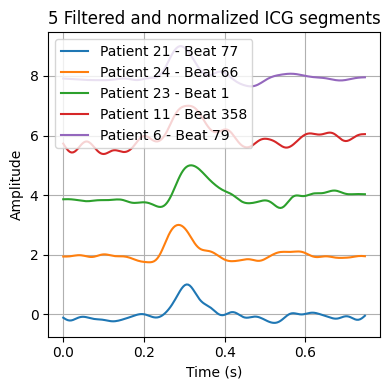

In [ ]:
def plot_random_icg_segments(df, fs=250, num_signals=5):
    """
    Muestra num_signals segmentos ICG aleatorios del DataFrame.

    Parámetros:
    - df: DataFrame con columna 'Segment' que contiene arrays de segmentos.
    - fs: Frecuencia de muestreo (Hz).
    - num_signals: Número de señales a graficar.
    """
    selected = df.sample(n=num_signals, random_state=42)  # Mismo resultado si se ejecuta varias veces
    time = np.linspace(0, len(selected.iloc[0]['Segment']) / fs, len(selected.iloc[0]['Segment']))

    plt.figure(figsize=(4, 4))
    for i, (_, row) in enumerate(selected.iterrows()):
        plt.plot(time, row['Segment'] + i * 2, label=f"Patient {row['PatientID']} - Beat {row['BeatNumber']}")

    plt.title(f'{num_signals} Filtered and normalized ICG segments')
    plt.xlabel('Time (s)')
    plt.ylabel('Amplitude')
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()
plot_random_icg_segments(df_segments)


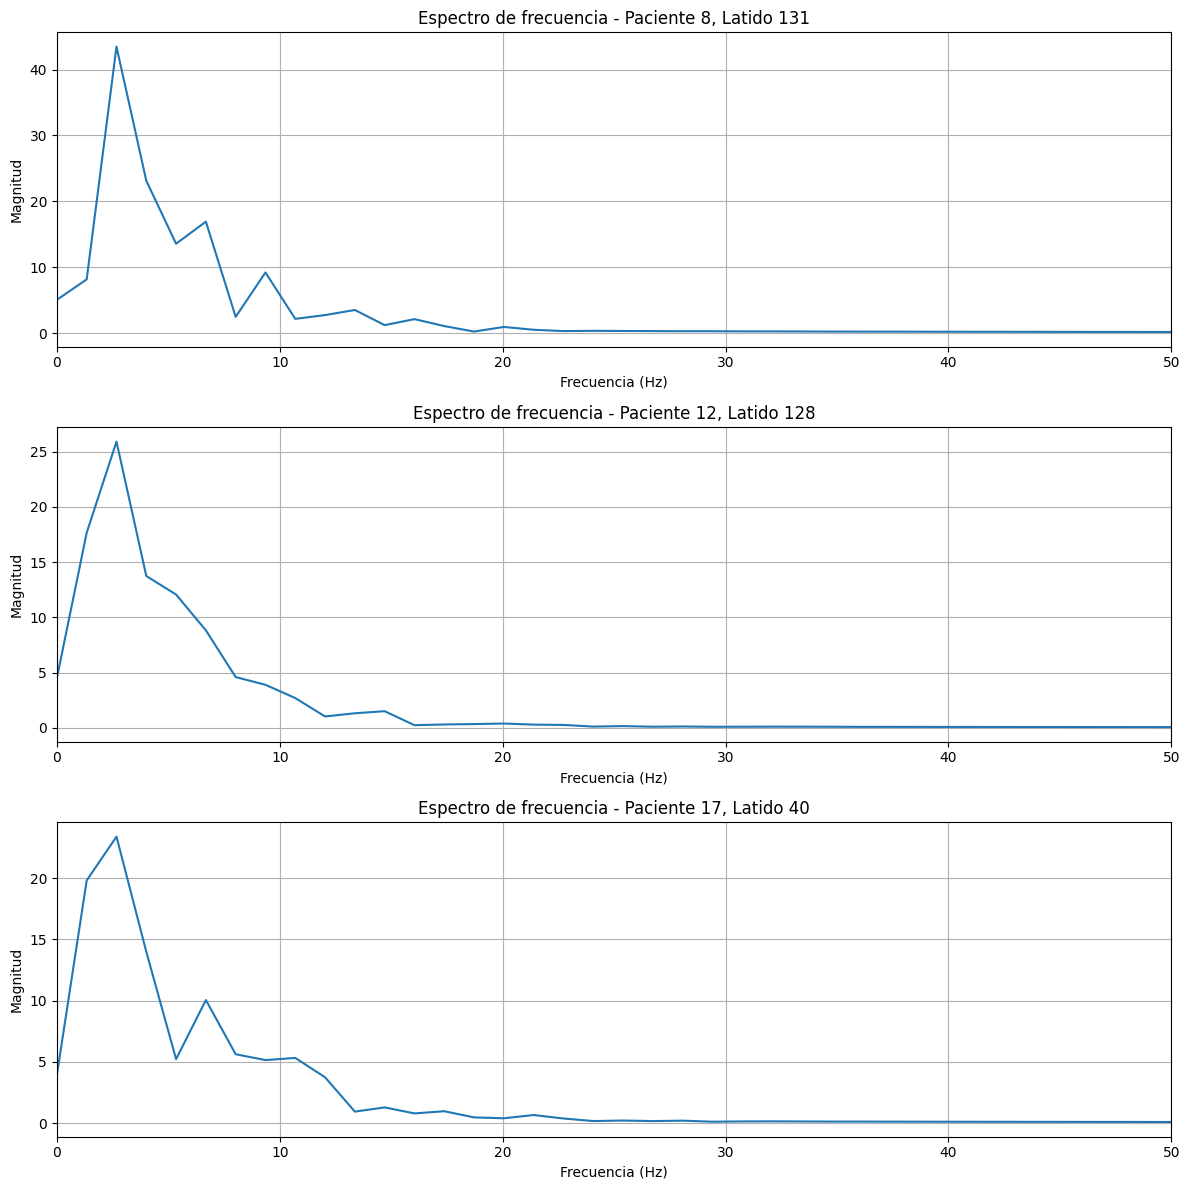

In [ ]:
def plot_fft_of_segments(df, fs=250, num_signals=3):
    selected = df.sample(n=num_signals, random_state=1)
    plt.figure(figsize=(12, 4 * num_signals))

    for i, (_, row) in enumerate(selected.iterrows()):
        signal = row['Segment']
        N = len(signal)
        freq = np.fft.rfftfreq(N, d=1/fs)
        fft_vals = np.abs(np.fft.rfft(signal))

        plt.subplot(num_signals, 1, i + 1)
        plt.plot(freq, fft_vals)
        plt.title(f'Espectro de frecuencia - Paciente {row["PatientID"]}, Latido {row["BeatNumber"]}')
        plt.xlabel('Frecuencia (Hz)')
        plt.ylabel('Magnitud')
        plt.grid(True)
        plt.xlim(0, 50)  # Nos centramos en el rango de interés

    plt.tight_layout()
    plt.show()
plot_fft_of_segments(df_segments)


Now we can observe that frequency range is between 0.5 and 20 Hz.

Next, we want to create a second dataset which, unlike the previous one, will include all subcomplexes except for subcomplex u. This is done so that, during clustering, subcomplexes of type u do not introduce noise, as they do not provide any useful information about the ICG.

Train a Random Forest model that, based on features extracted from each segment and the previously provided labels, is able to automatically classify each of the segments.


In [ ]:
"""
Versión mejorada que permite:
1. Ajustar fácilmente el **porcentaje de segmentos ‘U’** mediante un umbral de probabilidad (`PROB_THRESHOLD`).
2. Forzar una nueva ejecución eliminando cachés previos con `FORCE_RESET`.
3. Mostrar un resumen final del reparto V/U para que puedas iterar hasta aproximarte al 10 % de ‘U’.

Instrucciones rápidas
--------------------
* Si ya tienes **segment_labels.csv** y **rf_model.pkl**, el script sólo volverá a generar las predicciones.
* Cambia `PROB_THRESHOLD` (0–1).  Cuanto más alto, más exigente → más ‘U’.
* Pon `FORCE_RESET = True` si quieres ignorar/descartar los archivos guardados y empezar de cero.
"""


# ---------------------------------------------------------------------
# Configuración
# ---------------------------------------------------------------------
RANDOM_STATE   = 42           # reproducibilidad total
PROB_THRESHOLD = 0.75         # ↑ → más segmentos etiquetados como ‘U’
FORCE_RESET    = False        # True para ignorar etiquetas/modelo previos

LABELS_FILE        = Path("segment_labels.csv")
MODEL_FILE         = Path("rf_model.pkl")
PREDICTED_FILE     = Path("icg_segments_with_predictions.csv")
VALID_SEGMENTS_PKL = Path("segments_valid.pkl")

np.random.seed(RANDOM_STATE)

# ---------------------------------------------------------------------
# Función de extracción de características
# ---------------------------------------------------------------------

def extract_features(segments):
    feats = []
    for seg in segments:
        seg = np.asarray(seg)
        feats.append([
            np.mean(seg),
            np.std(seg),
            np.max(seg),
            np.min(seg),
            skew(seg),
            kurtosis(seg),
        ])
    return np.asarray(feats)

# ---------------------------------------------------------------------
# 0) Cargar df_segments
# ---------------------------------------------------------------------
assert "df_segments" in globals(), (
    "Debes tener cargado un DataFrame llamado df_segments con la columna 'Segment'."
)

# ---------------------------------------------------------------------
# 1) ¿Eliminar archivos previos?
# ---------------------------------------------------------------------
if FORCE_RESET:
    for f in [LABELS_FILE, MODEL_FILE, PREDICTED_FILE, VALID_SEGMENTS_PKL]:
        if f.exists():
            f.unlink()
    print("  Archivos antiguos eliminados — se inicia desde cero.")

# ---------------------------------------------------------------------
# 2) Cargar o crear etiquetas + modelo
# ---------------------------------------------------------------------
if LABELS_FILE.exists() and MODEL_FILE.exists():
    print(" Encontrados archivos previos. Cargando…")
    sampled_df = pd.read_csv(LABELS_FILE)
    with open(MODEL_FILE, "rb") as f:
        rf = pickle.load(f)
else:
    print(" No existen etiquetas/modelo. Procediendo a etiquetar 100 segmentos…")
    NUM_SAMPLES = 100
    BATCH_SIZE  = 4
    sampled_df  = df_segments.sample(NUM_SAMPLES, random_state=RANDOM_STATE).reset_index(drop=True)
    labels = []

    for i in range(0, NUM_SAMPLES, BATCH_SIZE):
        batch = sampled_df.iloc[i:i+BATCH_SIZE]
        fig, axs = plt.subplots(1, len(batch), figsize=(16,4))
        if len(batch) == 1:
            axs = [axs]
        for ax, (_, row) in zip(axs, batch.iterrows()):
            ax.plot(row["Segment"], lw=1)
            ax.set_title(f"Idx {row.name}")
            ax.grid(True)
        plt.tight_layout(); plt.show()

        display(HTML(
            f"<b>Introduce {len(batch)} etiquetas (V válido / U inválido) separadas por espacio:</b>"
        ))
        input("Pulsa Enter cuando estés lista para escribir las etiquetas…")
        while True:
            batch_labels = input("Etiquetas: ").upper().split()
            if len(batch_labels) == len(batch) and all(l in {"V","U"} for l in batch_labels):
                break
            print(" Revisa que has escrito la cantidad correcta y sólo V/U.")
        labels.extend(batch_labels)

    sampled_df["Label"] = labels
    sampled_df.to_csv(LABELS_FILE, index=False)
    files.download(LABELS_FILE)

    # Entrenamiento RF
    X = extract_features(sampled_df["Segment"])
    y = sampled_df["Label"].map({"V":1, "U":0}).to_numpy()
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.3, random_state=RANDOM_STATE, stratify=y)
    rf = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, class_weight="balanced")
    rf.fit(X_tr, y_tr)
    print("\n Evaluación en el 30 % de los etiquetados:")
    print(classification_report(y_te, rf.predict(X_te), target_names=["U","V"]))

    with open(MODEL_FILE, "wb") as f:
        pickle.dump(rf, f)
    files.download(MODEL_FILE)

# ---------------------------------------------------------------------
# 3) Aplicar modelo a todos los segmentos con umbral personalizado
# ---------------------------------------------------------------------
proba_all = rf.predict_proba(extract_features(df_segments["Segment"]))[:,1]  # prob de clase 'V'
df_segments["Predicted_Label"] = np.where(proba_all >= PROB_THRESHOLD, "V", "U")

# ---------------------------------------------------------------------
# 4) Guardar y descargar resultados
# ---------------------------------------------------------------------
df_segments.to_csv(PREDICTED_FILE, index=False)
files.download(PREDICTED_FILE)

valid_segments = df_segments[df_segments["Predicted_Label"] == "V"].copy()
valid_segments.to_pickle(VALID_SEGMENTS_PKL)
files.download(VALID_SEGMENTS_PKL)
VALID_SEGMENTS_CSV = "valid_segments.csv"
valid_segments.to_csv(VALID_SEGMENTS_CSV, index=False)

# ---------------------------------------------------------------------
# 5) Resumen rápido
# ---------------------------------------------------------------------
num_total = len(df_segments)
num_u     = (df_segments["Predicted_Label"] == "U").sum()
print(f"\n Resumen => Total beats: {num_total:,}  |  ‘U’: {num_u}  ({num_u / num_total:.2%})  |  ‘V’: {num_total - num_u}")


🔁 Encontrados archivos previos. Cargando…


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


🔎 Resumen => Total beats: 8,407  |  ‘U’: 363  (4.32%)  |  ‘V’: 8044


Pie chart to visualize the distribution of segments U and V.


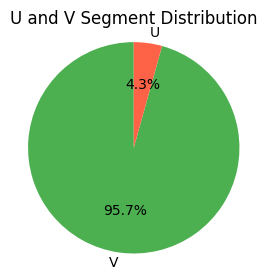

In [ ]:
# Contar la cantidad de segmentos de tipo V y U
label_counts = df_segments['Predicted_Label'].value_counts()

# Graficar distribución de segmentos V y U
plt.figure(figsize=(3, 3))
plt.pie(label_counts, labels=label_counts.index, autopct='%1.1f%%', startangle=90, colors=['#4CAF50', '#FF6347'])
plt.title("U and V Segment Distribution")
plt.axis('equal')  # Asegura que el gráfico sea un círculo
plt.show()


Code to visualize multiple U segments and verify:

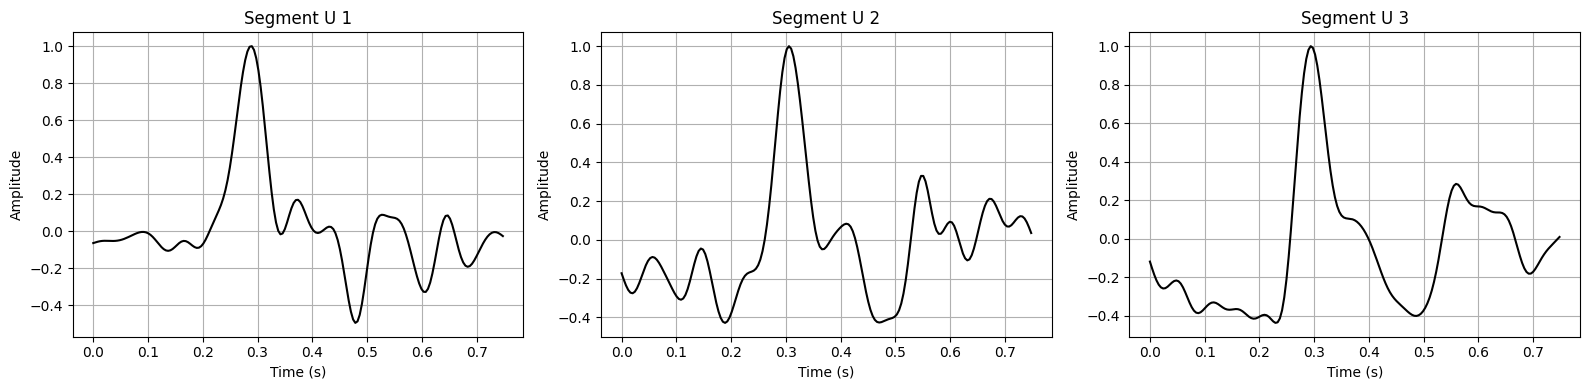

In [ ]:
# Filtrar los segmentos clasificados como 'U'
u_segments = df_segments[df_segments['Predicted_Label'] == 'U']

# Seleccionar un número aleatorio de segmentos 'U' para visualizar
num_segments_to_show = 3
random_u_segments = u_segments.sample(n=num_segments_to_show)

# Graficar los segmentos 'U' seleccionados
plt.figure(figsize=(16, 4))

for i, (_, row) in enumerate(random_u_segments.iterrows()):
    segment = np.array(row['Segment'])
    time_vector = np.linspace(0, len(segment) / fs, len(segment))  # Tiempo en segundos

    plt.subplot(1, num_segments_to_show, i + 1)
    plt.plot(time_vector, segment, color='black')
    plt.title(f"Segment U {i+1}")
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.grid(True)

plt.tight_layout()
plt.show()


Alright, we now have that the table icg_segments_with_predictions includes a new column indicating whether the segments are valid (V) or invalid (subcomplex U). Finally, the dataframe we will use in the following code will not be the entire one, but only the rows where the prediction column contains a V, that is the one saved as segments_valid.

###Delineation Algorithm of each Characteristic Point:

####C point detection:

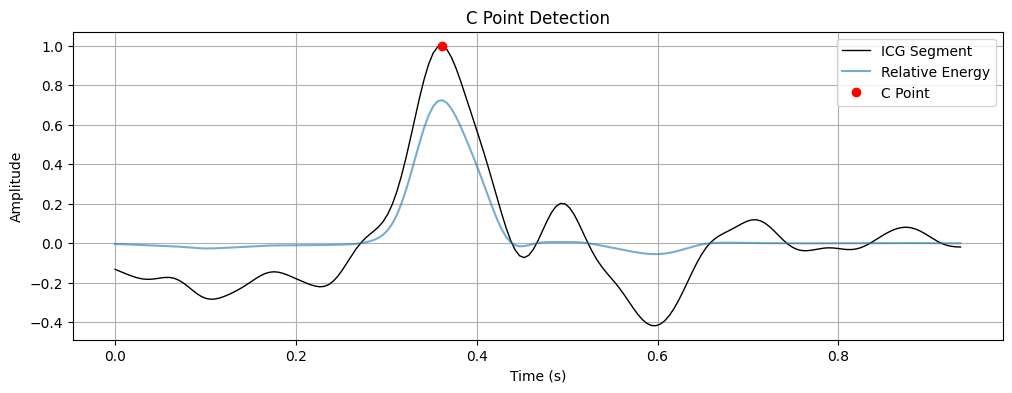

In [ ]:
def relative_energy(signal, fs, long_win=0.95, short_win=0.14):
    long_len = int(long_win * fs)
    short_len = int(short_win * fs)
    Xre = np.zeros_like(signal)

    for n in range(len(signal)):
        i1 = max(0, n - long_len // 2)
        i2 = min(len(signal), n + long_len // 2)
        long_energy = np.sum(signal[i1:i2] ** 2)

        j1 = max(0, n - short_len // 2)
        j2 = min(len(signal), n + short_len // 2)
        short_energy = np.sum(signal[j1:j2] ** 2)

        if long_energy != 0:
            c = short_energy / long_energy
            Xre[n] = signal[n] * c
    return Xre

def detect_C_peaks(icg_filtered, fs):
    Xre = relative_energy(icg_filtered, fs)

    # Thresholds
    sorted_peaks = np.sort(Xre[Xre > np.mean(Xre)])
    maxval = sorted_peaks[-2] if len(sorted_peaks) > 1 and sorted_peaks[-2] > np.mean(Xre) else sorted_peaks[-1]

    Thr_max = 0.2 * maxval
    Thr_min = 0.02 * maxval

    C_peaks = []
    active = False
    start_idx = 0

    for i in range(1, len(Xre)):
        if not active and Xre[i] > Thr_max:
            active = True
            start_idx = i
        elif active and Xre[i] < Thr_min:
            end_idx = i
            peak_idx = start_idx + np.argmax(Xre[start_idx:end_idx])
            if len(C_peaks) == 0 or (peak_idx - C_peaks[-1]) > int(0.25 * fs):
                C_peaks.append(peak_idx)
            active = False

    # Filtrar según intervalos C-C
    final_C_peaks = []
    for i, p in enumerate(C_peaks):
        if i < 5:
            final_C_peaks.append(p)
        else:
            prev_cc = np.diff(final_C_peaks[-5:])
            if len(prev_cc) == 5:
                avg_cc = np.mean(prev_cc)
                if (p - final_C_peaks[-1]) > 1.7 * avg_cc:
                    final_C_peaks.append(p)
            else:
                final_C_peaks.append(p)

    return np.array(final_C_peaks), Xre

#Cogemos un segmento de icg cuya etiqueta sea V
icg_segment = valid_segments['Segment'].iloc[1000]
fs=200
C_peaks, Xre = detect_C_peaks(icg_segment, fs)

#Definimos el tiempo para representar en función del tiempo en lugar de muestras
tiempo = np.linspace(0, len(icg_segment)/fs, len(icg_segment))

# Representación
plt.figure(figsize=(12, 4))
plt.plot(tiempo, icg_segment, label="ICG Segment", color='black', linewidth=1)
plt.plot(tiempo, Xre, label="Relative Energy", alpha=0.6)
plt.plot(tiempo[C_peaks], icg_segment[C_peaks], 'ro', label="C Point")
plt.legend()
plt.title("C Point Detection")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.grid(True)
plt.show()


####B point detection:

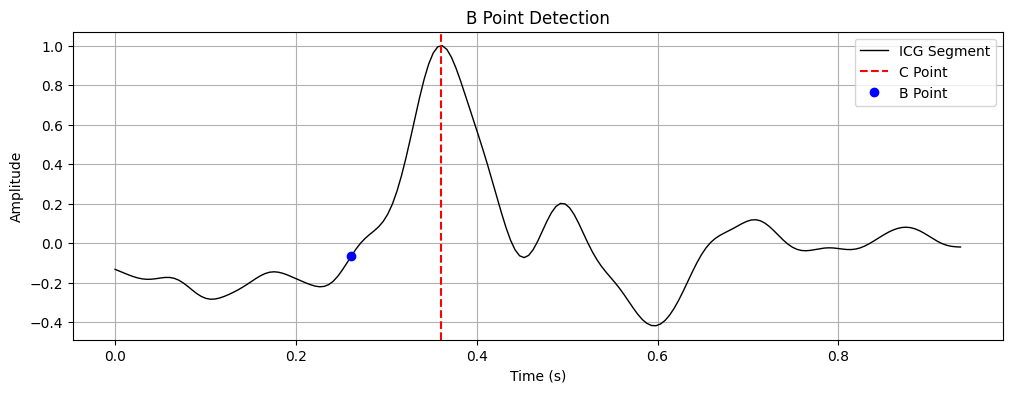

In [ ]:
def find_B_point(icg_segment, Cpos, fs, Afrac=0.2, Bslope1=0.11, Bslope2=0.08):
    # Paso 1: calcular límites de la ventana de búsqueda
    BlimL = max(0, int(Cpos - 0.1 * fs))  # 80 ms antes del C
    C_amp = icg_segment[Cpos]

    # Buscar BlimR: el índice más cercano a la izquierda donde la señal < Afrac * C_amp
    for i in range(Cpos - 1, BlimL, -1):
        if icg_segment[i] <= Afrac * C_amp:
            BlimR = i
            break
    else:
        BlimR = BlimL  # Si no se encuentra, que sea igual al límite inferior

    # Derivada primera (pendiente) de la señal
    slope = np.gradient(icg_segment)

    # Paso 2: búsqueda con Bslope1
    for i in range(BlimR, BlimL, -1):
        if (i > 0 and (icg_segment[i] < icg_segment[i-1])) or abs(slope[i]) > Bslope1:
            return i

    # Paso 3: búsqueda con Bslope2
    for i in range(BlimR, BlimL, -1):
        if abs(slope[i]) > Bslope2:
            return i

    # Paso 4: si no se encuentra, retornar el mínimo de la ventana
    search_region = icg_segment[BlimL:BlimR+1]
    return BlimL + np.argmin(search_region)

B_points = []
for Cpos in C_peaks:
    B_idx = find_B_point(icg_segment, Cpos, fs)
    B_points.append(B_idx)

# Visualización
plt.figure(figsize=(12, 4))
plt.plot(tiempo, icg_segment, label="ICG Segment", color='black', linewidth=1)
plt.axvline(x=C_peaks / fs, color='red', linestyle='--', label='C Point')
#plt.plot(tiempo[C_peaks], icg_segment[C_peaks], 'ro', label="C Point")
plt.plot(tiempo[B_points], icg_segment[B_points], 'bo', label="B Point")
plt.legend()
plt.title("B Point Detection")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.grid(True)
plt.show()


####X point detection:

<ipython-input-15-da81d4f2b8cc>:6: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  start = max(int(C_index + CXmin_samp), 0)
<ipython-input-15-da81d4f2b8cc>:7: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  end = min(int(C_index + CXmax_samp), len(icg_segment) - 1)


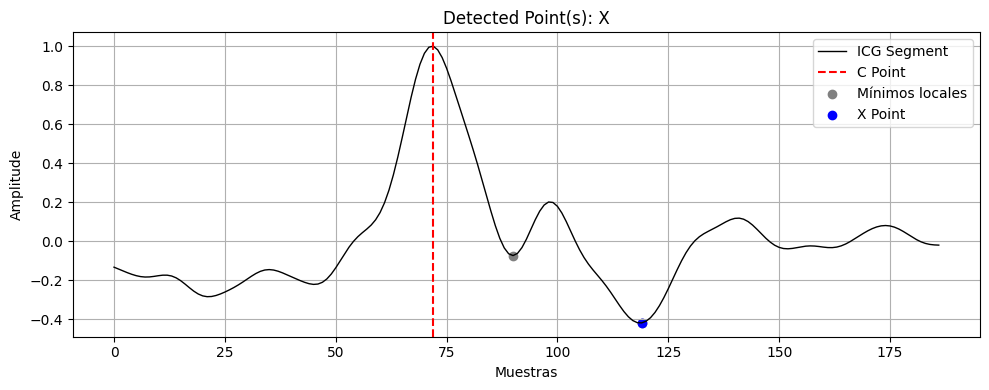

{'caso': 'X', 'X': np.int64(119)}


In [ ]:
def detectar_punto_X(icg_segment, C_index, fs, plot=False, suavizar=True):

    # 1. Definir ventana temporal (0.1s a 0.4s después de C)
    CXmin_s, CXmax_s = 0.05, 0.4
    CXmin_samp, CXmax_samp = int(fs * CXmin_s), int(fs * CXmax_s)
    start = max(int(C_index + CXmin_samp), 0)
    end = min(int(C_index + CXmax_samp), len(icg_segment) - 1)
    ventana = icg_segment[start:end]

    if len(ventana) < 3:
        return {"caso": "ninguno", "mensaje": "Ventana demasiado corta"}

    # 2. Suavizar señal si está activado
    if suavizar:
        ventana = gaussian_filter1d(ventana, sigma=1)

    # 3. Detectar mínimos locales
    min_indices = argrelextrema(ventana, np.less)[0]
    if len(min_indices) == 0:
        return {"caso": "ninguno", "mensaje": "No se detectaron mínimos locales"}

    # 4. Detectar mínimo global
    abs_min_idx = np.argmin(ventana)

    # 5. Clasificación según mínimos detectados
    if len(min_indices) == 1:
        idx = min_indices[0]
        if idx == abs_min_idx and (C_index + 0.07 <= idx <= C_index + 0.22):
            resultado = {"caso": "X1", "X1": idx}
        else:
            resultado = {"caso": "X", "X": abs_min_idx}

    elif len(min_indices) == 2:
        # Tomar los dos primeros mínimos locales
        X1_idx = min_indices[0]
        X2_idx = min_indices[1]

        # Comparar amplitudes
        amp_diff = abs(ventana[X1_idx] - ventana[X2_idx])
        amplitud_umbral = 0.05  # Puedes ajustar este valor según tu dataset

        if ventana[X1_idx] < ventana[X2_idx] and amp_diff <= amplitud_umbral:
            resultado = {"caso": "X1_X2", "X1": X1_idx, "X2": X2_idx}
        elif ventana[X1_idx] > ventana[X2_idx] and amp_diff <= amplitud_umbral:
            resultado = {"caso": "X1_X2", "X1": X1_idx, "X2": X2_idx}
        elif ventana[X1_idx] > ventana[X2_idx]:
            resultado = {"caso": "X", "X": X2_idx}
        else:
            resultado = {"caso": "X", "X": abs_min_idx}

    elif len(min_indices) >= 3:
        # Tomar los tres primeros mínimos locales
        X1_idx = min_indices[0]
        X2_idx = min_indices[1]
        X3_idx = min_indices[2]

        amp_diff = abs(ventana[X1_idx] - ventana[X2_idx])
        amplitud_umbral = 0.05  # Puedes ajustar este valor según tu dataset

        if ventana[X1_idx] < ventana[X2_idx] and amp_diff <= amplitud_umbral:
            resultado = {"caso": "X1_X2", "X1": X1_idx, "X2": X2_idx}

        elif ventana[X1_idx] > ventana[X2_idx] and amp_diff <= amplitud_umbral:
            resultado = {"caso": "X1_X2", "X1": X1_idx, "X2": X2_idx}

        elif ventana[X3_idx] < ventana[X2_idx]:
            resultado = {"caso": "X", "X": X3_idx}

        else:
            resultado = {"caso": "X", "X": abs_min_idx}

    # 6. Graficar resultados
    if plot:
        plt.figure(figsize=(10, 4))
        plt.plot(icg_segment, label='ICG Segment', color='black', linewidth=1)
        plt.axvline(x=C_index, color='red', linestyle='--', label='C Point')

        # Ajustar índices locales a posición original
        min_plot_idx = min_indices + start
        plt.scatter(min_plot_idx, icg_segment[min_plot_idx], color='gray', label='Mínimos locales')

        if resultado["caso"] == "X":
            plt.scatter(resultado["X"] + start, icg_segment[resultado["X"] + start], color='blue', label='X Point')
        elif resultado["caso"] == "X1":
            plt.scatter(resultado["X1"] + start, icg_segment[resultado["X1"] + start], color='orange', label='X1 Point')
        elif resultado["caso"] == "X1_X2":
                plt.scatter(resultado["X1"] + start, icg_segment[resultado["X1"] + start],
                color='orange', label='X1 Point')
                plt.scatter(resultado["X2"] + start, icg_segment[resultado["X2"] + start],
                color='blue', label='X2 Point')
        plt.title(f"Detected Point(s): {resultado['caso']}")
        plt.xlabel("Muestras")
        plt.ylabel("Amplitude")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()


    # Ajustar índices al segmento original
    if resultado["caso"] == "X":
        resultado["X"] = resultado["X"] + start
    elif resultado["caso"] == "X1":
        resultado["X1"] = resultado["X1"] + start
    elif resultado["caso"] == "X1_X2":
        resultado["X1"] = resultado["X1"] + start
        resultado["X2"] = resultado["X2"] + start

    return resultado

segmento = valid_segments['Segment'].iloc[1000]
fs = 200
C_index, _ = detect_C_peaks(segmento, fs)

resultado = detectar_punto_X(segmento, C_index, fs, plot=True)
print(resultado)

Detection versus time

<ipython-input-16-dfb2d99cb691>:6: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  start = max(int(C_index + CXmin_samp), 0)
<ipython-input-16-dfb2d99cb691>:7: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  end = min(int(C_index + CXmax_samp), len(icg_segment) - 1)


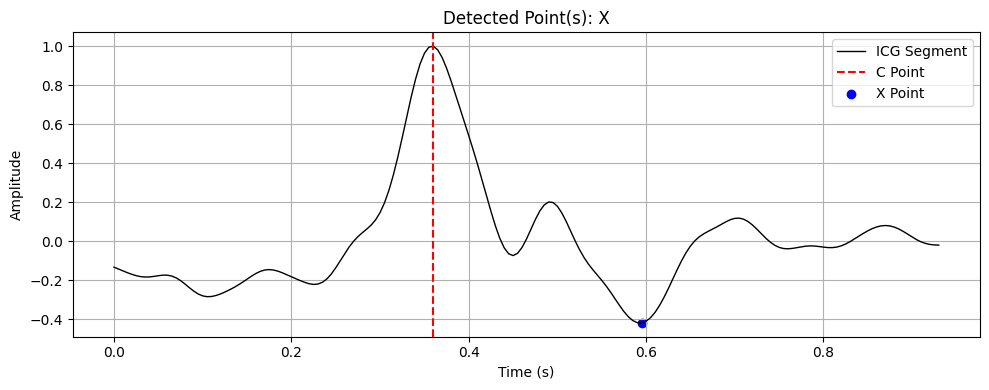

{'caso': 'X', 'X': np.int64(119)}


In [ ]:
def detectar_punto_X(icg_segment, C_index, fs, plot=False, suavizar=True):

    # 1. Definir ventana temporal (0.1s a 0.4s después de C)
    CXmin_s, CXmax_s = 0.05, 0.4
    CXmin_samp, CXmax_samp = int(fs * CXmin_s), int(fs * CXmax_s)
    start = max(int(C_index + CXmin_samp), 0)
    end = min(int(C_index + CXmax_samp), len(icg_segment) - 1)
    ventana = icg_segment[start:end]

    if len(ventana) < 3:
        return {"caso": "ninguno", "mensaje": "Ventana demasiado corta"}

    # 2. Suavizar señal si está activado
    if suavizar:
        ventana = gaussian_filter1d(ventana, sigma=1)

    # 3. Detectar mínimos locales
    min_indices = argrelextrema(ventana, np.less)[0]
    if len(min_indices) == 0:
        return {"caso": "ninguno", "mensaje": "No se detectaron mínimos locales"}

    # 4. Detectar mínimo global
    abs_min_idx = np.argmin(ventana)

    # 5. Clasificación según mínimos detectados
    if len(min_indices) == 1:
        idx = min_indices[0]
        if idx == abs_min_idx and (C_index + 0.07 <= idx <= C_index + 0.22):
            resultado = {"caso": "X1", "X1": idx}
        else:
            resultado = {"caso": "X", "X": abs_min_idx}

    elif len(min_indices) == 2:
        # Tomar los dos primeros mínimos locales
        X1_idx = min_indices[0]
        X2_idx = min_indices[1]

        # Comparar amplitudes
        amp_diff = abs(ventana[X1_idx] - ventana[X2_idx])
        amplitud_umbral = 0.05  # Puedes ajustar este valor según tu dataset
        idx = min_indices[0]

        if ventana[X1_idx] < ventana[X2_idx] and amp_diff <= amplitud_umbral:
            resultado = {"caso": "X1_X2", "X1": X1_idx, "X2": X2_idx}

        elif idx == abs_min_idx :
            resultado = {"caso": "X1", "X1": idx}
        elif ventana[X1_idx] > ventana[X2_idx] and amp_diff <= amplitud_umbral:
            resultado = {"caso": "X1_X2", "X1": X1_idx, "X2": X2_idx}
        elif ventana[X1_idx] > ventana[X2_idx]:
            resultado = {"caso": "X", "X": X2_idx}
        else:
            resultado = {"caso": "X", "X": abs_min_idx}

    elif len(min_indices) >= 3:
        # Tomar los tres primeros mínimos locales
        X1_idx = min_indices[0]
        X2_idx = min_indices[1]
        X3_idx = min_indices[2]

        amp_diff = abs(ventana[X1_idx] - ventana[X2_idx])
        amplitud_umbral = 0.05  # Puedes ajustar este valor según tu dataset
        idx = min_indices[0]

        if ventana[X1_idx] < ventana[X2_idx] and amp_diff <= amplitud_umbral:
            resultado = {"caso": "X1_X2", "X1": X1_idx, "X2": X2_idx}

        elif ventana[X1_idx] > ventana[X2_idx] and amp_diff <= amplitud_umbral:
            resultado = {"caso": "X1_X2", "X1": X1_idx, "X2": X2_idx}

        elif idx == abs_min_idx :
            resultado = {"caso": "X1", "X1": idx}
        elif ventana[X3_idx] < ventana[X2_idx]:
            resultado = {"caso": "X", "X": X3_idx}

        else:
            resultado = {"caso": "X", "X": abs_min_idx}

    # 6. Graficar resultados
    # 5. Clasificación según mínimos detectados
    # [ ... aquí tu lógica de detección ... ]

    # 🔁 Ajustar índices al segmento original ANTES de graficar
    if resultado["caso"] == "X":
        resultado["X"] = resultado["X"] + start
    elif resultado["caso"] == "X1":
        resultado["X1"] = resultado["X1"] + start
    elif resultado["caso"] == "X1_X2":
        resultado["X1"] = resultado["X1"] + start
        resultado["X2"] = resultado["X2"] + start

    # 6. Graficar resultados EN TIEMPO
    if plot:
        plt.figure(figsize=(10, 4))
        tiempo_segmento = np.arange(len(icg_segment)) / fs
        plt.plot(tiempo_segmento, icg_segment, label='ICG Segment', color='black', linewidth=1)
        plt.axvline(x=C_index / fs, color='red', linestyle='--', label='C Point')


        if resultado["caso"] == "X":
            plt.scatter(resultado["X"] / fs, icg_segment[resultado["X"]], color='blue', label='X Point')
        elif resultado["caso"] == "X1":
            plt.scatter(resultado["X1"] / fs, icg_segment[resultado["X1"]], color='orange', label='X1 Point')
        elif resultado["caso"] == "X1_X2":
            plt.scatter(resultado["X1"] / fs, icg_segment[resultado["X1"]], color='orange', label='X1 Point')
            plt.scatter(resultado["X2"] / fs, icg_segment[resultado["X2"]], color='blue', label='X2 Point')

        plt.title(f"Detected Point(s): {resultado['caso']}")
        plt.xlabel("Time (s)")
        plt.ylabel("Amplitude")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()

    return resultado

segmento = valid_segments['Segment'].iloc[1000]
fs = 200
C_index, _ = detect_C_peaks(segmento, fs)

resultado = detectar_punto_X(segmento, C_index, fs, plot=True)
print(resultado)

####O point detection:

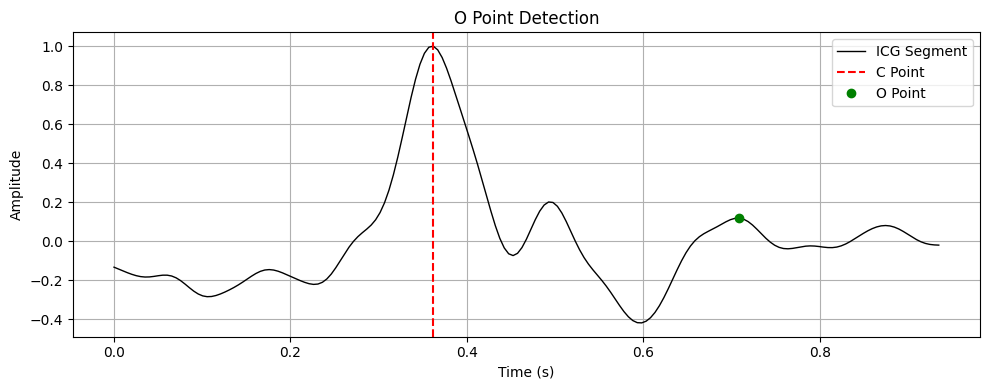

In [ ]:
def detect_O_point(segment, C_index, fs):
    # Zona de búsqueda: 0.2s a 0.5s después del punto C
    start_search = C_index + int(0.2 * fs)
    end_search = C_index + int(0.5 * fs)
    end_search = min(end_search, len(segment))  # evitar salir del rango

    search_region = segment[start_search:end_search]

    if len(search_region) == 0:
        return None

    # Buscar máximos locales
    peaks, _ = signal.find_peaks(search_region)

    if len(peaks) == 0:
        return None

    # Elegir el pico de mayor amplitud
    peak_amplitudes = search_region[peaks]
    max_peak_idx = peaks[np.argmax(peak_amplitudes)]
    O_index = start_search + max_peak_idx
    return O_index

# Supongamos que tienes `C_peaks`, `icg_segment`, y `fs` definidos
if len(C_peaks) > 0:
    C_idx = C_peaks[0]
    O_idx = detect_O_point(icg_segment, C_idx, fs)

    # Representación
    tiempo = np.linspace(0, len(icg_segment) / fs, len(icg_segment))
    plt.figure(figsize=(10, 4))
    plt.plot(tiempo, icg_segment, label="ICG Segment", color='black', linewidth=1)

    # Punto C como línea discontinua roja
    plt.axvline(x=tiempo[C_idx], color='red', linestyle='--', label="C Point")

    # Punto O como marcador
    if O_idx is not None:
        plt.plot(tiempo[O_idx], icg_segment[O_idx], 'go', label="O Point")

    plt.legend()
    plt.title("O Point Detection")
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


####Z point detection:

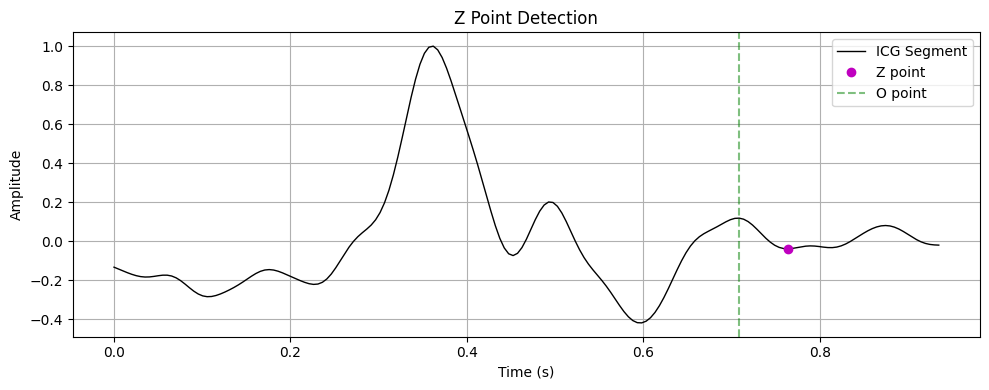

In [ ]:
def detect_Z_point(segment, O_index, fs):
    # Define search window (start just after O, up to 0.1s after)
    start_search = O_index + int(0.005 * fs)
    end_search = O_index + int(0.15 * fs)
    end_search = min(end_search, len(segment))

    # Extract search region
    search_region = segment[start_search:end_search]

    if len(search_region) == 0:
        return None

    # Invert the signal to find local minima as peaks
    inverted_region = -search_region
    peaks, _ = signal.find_peaks(inverted_region)

    if len(peaks) == 0:
        return None  # No local minima found

    # Choose the first local minimum
    Z_index = start_search + peaks[0]
    return Z_index

# Example of usage (assuming icg_segment, fs, and O_idx are defined)
Z_idx = detect_Z_point(icg_segment, O_idx, fs)

# Time vector for plotting
tiempo = np.linspace(0, len(icg_segment)/fs, len(icg_segment))

# Plotting the ICG signal with O and Z points
plt.figure(figsize=(10, 4))
plt.plot(tiempo, icg_segment, label="ICG Segment", color='black', linewidth=1,)
#plt.plot(tiempo[O_idx], icg_segment[O_idx], 'go', label="O point")
if Z_idx is not None:
    plt.plot(tiempo[Z_idx], icg_segment[Z_idx], 'mo', label="Z point")
    #plt.axvline(tiempo[Z_idx], color='m', linestyle='--', alpha=0.5)
plt.axvline(tiempo[O_idx], color='g', linestyle='--', alpha=0.5, label="O point")
plt.title("Z Point Detection")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


####Y point detection:

<ipython-input-16-dfb2d99cb691>:6: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  start = max(int(C_index + CXmin_samp), 0)
<ipython-input-16-dfb2d99cb691>:7: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  end = min(int(C_index + CXmax_samp), len(icg_segment) - 1)


Usando X_idx en detectar_punto_Y: 119
No se detectaron mínimos locales entre X y O.


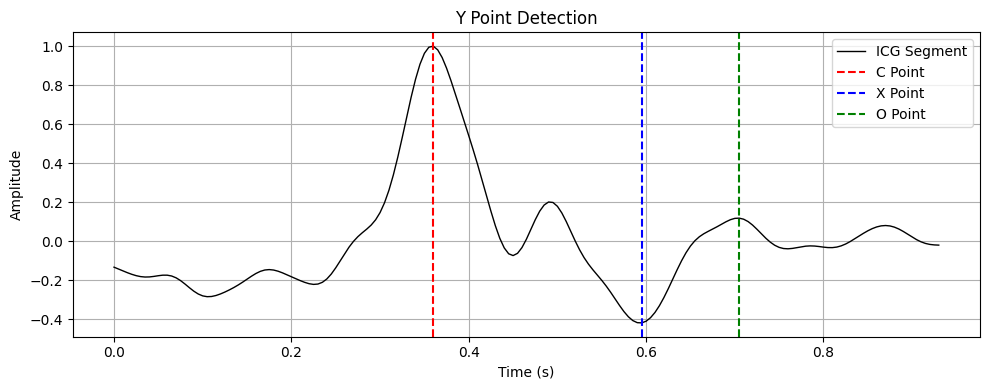

In [ ]:
def detectar_punto_Y(icg_segment, resultado_X, O_index):
    # Determinar índice de inicio según el caso X
    if resultado_X["caso"] == "X":
        X_idx = resultado_X["X"]
    elif resultado_X["caso"] == "X1":
        X_idx = resultado_X["X1"]
    elif resultado_X["caso"] == "X1_X2":
        X_idx = resultado_X["X2"]  # usar X2 en este caso
    else:
        print("No se puede detectar Y: caso X no válido.")
        return None

    print("Usando X_idx en detectar_punto_Y:", X_idx)

    # Validar que X esté antes que O
    if X_idx >= O_index:
        print("No se puede detectar Y: X ocurre después de O.")
        return None

    # Extraer segmento entre X y O
    ventana_Y = icg_segment[X_idx:O_index + 1]

    # Buscar mínimos locales en esta ventana
    min_indices = argrelextrema(ventana_Y, np.less)[0]

    if len(min_indices) == 0:
        print("No se detectaron mínimos locales entre X y O.")
        return None

    # Tomar el mínimo local de menor amplitud
    Y_rel_idx = min_indices[np.argmin(ventana_Y[min_indices])]
    Y_abs_idx = X_idx + Y_rel_idx

    return Y_abs_idx


def plot_segmento_con_puntos(segmento, fs, C_idx=None, X_idx=None, O_idx=None, Y_idx=None):
    tiempo = np.arange(len(segmento)) / fs  # Convertir muestras a tiempo (s)

    plt.figure(figsize=(10, 4))
    plt.plot(tiempo, segmento, label="ICG Segment", color='black', linewidth=1)

    if C_idx is not None:
        plt.axvline(x=C_idx / fs, color='red', linestyle='--', label="C Point")
        # plt.scatter([C_idx / fs], [segmento[C_idx]], color='red')

    if X_idx is not None:
        plt.axvline(x=X_idx / fs, color='blue', linestyle='--', label="X Point")
        # plt.scatter([X_idx / fs], [segmento[X_idx]], color='blue')

    if O_idx is not None:
        plt.axvline(x=O_idx / fs, color='green', linestyle='--', label="O Point")
        # plt.scatter([O_idx / fs], [segmento[O_idx]], color='green')

    if Y_idx is not None:
        plt.scatter([Y_idx / fs], [segmento[Y_idx]], color='magenta', label="Y Point")

    plt.legend()
    plt.title("Y Point Detection")
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

segmento = valid_segments['Segment'].iloc[1000]
fs = 200
C_index, _ = detect_C_peaks(segmento, fs)
resultado = detectar_punto_X(segmento, C_index, fs, plot=False)
C_idx = C_index[0]
O_idx = detect_O_point(segmento, C_idx, fs)
Y_idx = detectar_punto_Y(segmento, resultado, O_idx)

# Aquí usas la función externa para plotear todos los puntos
if resultado["caso"] == "X":
    X_idx = resultado["X"]
elif resultado["caso"] == "X1":
    X_idx = resultado["X1"]
elif resultado["caso"] == "X1_X2":
    X_idx = resultado["X2"]
else:
    X_idx = None

plot_segmento_con_puntos(segmento, fs, C_idx=C_index[0], X_idx=X_idx, O_idx=O_idx, Y_idx=Y_idx)

###Delineation Algorithm of all Characteristic Points:

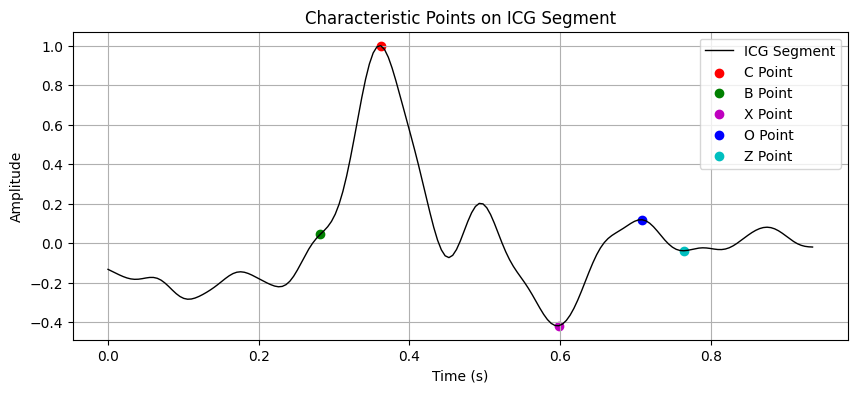

In [ ]:
# ===================== #
#    1. FUNCIONES       #
# ===================== #

def relative_energy(signal, fs, long_win=0.95, short_win=0.14):
    long_len = int(long_win * fs)
    short_len = int(short_win * fs)
    Xre = np.zeros_like(signal)
    for n in range(len(signal)):
        i1, i2 = max(0, n - long_len // 2), min(len(signal), n + long_len // 2)
        j1, j2 = max(0, n - short_len // 2), min(len(signal), n + short_len // 2)
        long_energy = np.sum(signal[i1:i2] ** 2)
        short_energy = np.sum(signal[j1:j2] ** 2)
        if long_energy != 0:
            Xre[n] = signal[n] * (short_energy / long_energy)
    return Xre


def detect_C_peaks(icg_filtered, fs):
    Xre = relative_energy(icg_filtered, fs)
    sorted_peaks = np.sort(Xre[Xre > np.mean(Xre)])
    maxval = sorted_peaks[-2] if len(sorted_peaks) > 1 else sorted_peaks[-1]
    Thr_max, Thr_min = 0.2 * maxval, 0.02 * maxval

    C_peaks, active = [], False
    for i in range(1, len(Xre)):
        if not active and Xre[i] > Thr_max:
            active, start_idx = True, i
        elif active and Xre[i] < Thr_min:
            end_idx = i
            peak_idx = start_idx + np.argmax(Xre[start_idx:end_idx])
            if not C_peaks or (peak_idx - C_peaks[-1]) > int(0.25 * fs):
                C_peaks.append(peak_idx)
            active = False

    final_C_peaks = []
    for i, p in enumerate(C_peaks):
        if i < 5:
            final_C_peaks.append(p)
        else:
            prev_cc = np.diff(final_C_peaks[-5:])
            avg_cc = np.mean(prev_cc)
            if (p - final_C_peaks[-1]) > 1.7 * avg_cc:
                final_C_peaks.append(p)
    return np.array(final_C_peaks), Xre


def find_B_point(icg_segment, Cpos, fs, Afrac=0.2, Bslope1=0.11, Bslope2=0.08):
    BlimL = max(0, int(Cpos - 0.08 * fs))
    for i in range(Cpos - 1, BlimL, -1):
        if icg_segment[i] <= Afrac * icg_segment[Cpos]:
            BlimR = i
            break
    else:
        BlimR = BlimL
    slope = np.gradient(icg_segment)
    for i in range(BlimR, BlimL, -1):
        if (i > 0 and icg_segment[i] < icg_segment[i-1]) or abs(slope[i]) > Bslope1:
            return i
    for i in range(BlimR, BlimL, -1):
        if abs(slope[i]) > Bslope2:
            return i
    return BlimL + np.argmin(icg_segment[BlimL:BlimR+1])


def detectar_punto_X(icg_segment, C_index, fs, plot=False, suavizar=True):
    # 1. Definir ventana temporal (0.05s a 0.4s después de C)
    CXmin_s, CXmax_s = 0.05, 0.4
    CXmin_samp, CXmax_samp = int(fs * CXmin_s), int(fs * CXmax_s)
    start = max(int(C_index + CXmin_samp), 0)
    end = min(int(C_index + CXmax_samp), len(icg_segment) - 1)
    ventana = icg_segment[start:end]

    if len(ventana) < 3:
        return {"caso": "ninguno", "mensaje": "Ventana demasiado corta"}

    # 2. Suavizar señal si está activado
    if suavizar:
        ventana = gaussian_filter1d(ventana, sigma=1)

    # 3. Detectar mínimos locales
    min_indices = argrelextrema(ventana, np.less)[0]
    if len(min_indices) == 0:
        return {"caso": "ninguno", "mensaje": "No se detectaron mínimos locales"}

    # 4. Detectar mínimo global
    abs_min_idx = np.argmin(ventana)

    # 5. Clasificación según mínimos detectados
    if len(min_indices) == 1:
        idx = min_indices[0]
        if idx == abs_min_idx and (0.07*fs <= idx <= 0.22*fs):
            resultado = {"caso": "X1", "X1": idx}
        else:
            resultado = {"caso": "X", "X": abs_min_idx}

    elif len(min_indices) == 2:
        X1_idx, X2_idx = min_indices[0], min_indices[1]
        amp_diff = abs(ventana[X1_idx] - ventana[X2_idx])
        umbral = 0.05
        idx = min_indices[0]
        if ventana[X1_idx] < ventana[X2_idx] and amp_diff <= umbral:
            resultado = {"caso": "X1_X2", "X1": X1_idx, "X2": X2_idx}
        elif ventana[X1_idx] > ventana[X2_idx] and amp_diff <= umbral:
            resultado = {"caso": "X1_X2", "X1": X1_idx, "X2": X2_idx}
        elif idx == abs_min_idx and (0.07*fs <= idx <= 0.22*fs):
            resultado = {"caso": "X1", "X1": idx}
        elif ventana[X1_idx] > ventana[X2_idx]:
            resultado = {"caso": "X", "X": X2_idx}
        else:
            resultado = {"caso": "X", "X": abs_min_idx}

    else:
        X1_idx, X2_idx, X3_idx = min_indices[:3]
        amp_diff = abs(ventana[X1_idx] - ventana[X2_idx])
        umbral = 0.05
        idx = min_indices[0]
        if ventana[X1_idx] < ventana[X2_idx] and amp_diff <= umbral:
            resultado = {"caso": "X1_X2", "X1": X1_idx, "X2": X2_idx}
        elif ventana[X1_idx] > ventana[X2_idx] and amp_diff <= umbral:
            resultado = {"caso": "X1_X2", "X1": X1_idx, "X2": X2_idx}
        elif idx == abs_min_idx and (0.07*fs <= idx <= 0.22*fs):
            resultado = {"caso": "X1", "X1": idx}
        elif ventana[X3_idx] < ventana[X2_idx]:
            resultado = {"caso": "X", "X": X3_idx}
        else:
            resultado = {"caso": "X", "X": abs_min_idx}

    # Ajuste de índices absolutos
    if resultado["caso"] == "X":
        resultado["X"] += start
    elif resultado["caso"] == "X1":
        resultado["X1"] += start
    elif resultado["caso"] == "X1_X2":
        resultado["X1"] += start
        resultado["X2"] += start

    return resultado


def detect_O_point(segment, C_index, fs):
    start_search = C_index + int(0.2 * fs)
    end_search = min(C_index + int(0.5 * fs), len(segment))
    search_region = segment[start_search:end_search]
    if len(search_region) == 0:
        return None
    peaks, _ = signal.find_peaks(search_region)
    if len(peaks) == 0:
        return None
    max_peak_idx = peaks[np.argmax(search_region[peaks])]
    return start_search + max_peak_idx


def detect_Z_point(segment, O_index, fs):
    # Define search window (start just after O, up to 0.1s after)
    start_search = O_index + int(0.005 * fs)
    end_search = O_index + int(0.15 * fs)
    end_search = min(end_search, len(segment))

    # Extract search region
    search_region = segment[start_search:end_search]

    if len(search_region) == 0:
        return None

    # Invert the signal to find local minima as peaks
    inverted_region = -search_region
    peaks, _ = signal.find_peaks(inverted_region)

    if len(peaks) == 0:
        return None  # No local minima found

    # Choose the first local minimum
    Z_index = start_search + peaks[0]
    return Z_index



def detectar_punto_Y(icg_segment, resultado_X, O_index, fs):
    # Selección del índice de X
    if resultado_X["caso"] == "X":
        X_idx = resultado_X["X"]
    elif resultado_X["caso"] == "X1":
        X_idx = resultado_X["X1"]
    elif resultado_X["caso"] == "X1_X2":
        X_idx = resultado_X["X2"]
    else:
        return None

    if X_idx >= O_index:
        return None

    # Definir ventana temporal tras X
    min_offset = int(0.06 * fs)  # 60 ms
    max_offset = O_index
    inicio = X_idx + min_offset
    fin = min(X_idx + max_offset, O_index + 1)

    if fin <= inicio or fin > len(icg_segment):
        return None

    ventana_Y = icg_segment[inicio:fin]

    # Detectar mínimos locales
    min_idx = argrelextrema(ventana_Y, np.less)[0]

    for idx in min_idx:
        # Verificar que la curva baja antes y sube después (mínimo local "válido")
        if 1 <= idx < len(ventana_Y) - 1:
            if ventana_Y[idx - 1] > ventana_Y[idx] < ventana_Y[idx + 1]:
                return inicio + idx

    # Si no hay mínimos válidos con esa forma
    return None
# ===================== #
#     2. CARGA & PLOT   #
# ===================== #

fs = 200
segmento_idx = 1000
segmento = valid_segments['Segment'].iloc[segmento_idx]

# Detectar todos los puntos
C_peaks, _ = detect_C_peaks(segmento, fs)
B_points = find_B_point(segmento, C_peaks[0], fs)
X_result = detectar_punto_X(segmento, C_peaks[0], fs)
O_point = detect_O_point(segmento, C_peaks[0], fs)
Z_point = detect_Z_point(segmento, O_point, fs)
Y_point = detectar_punto_Y(segmento, X_result, O_point, fs)

def plot_icg_with_points(icg_segment, fs,
                         C_idx, B_idxs, X_res, O_idx, Z_idx, Y_idx):
    time = np.linspace(0, len(icg_segment)/fs, len(icg_segment))
    plt.figure(figsize=(10,4))
    plt.plot(time, icg_segment, color='k', label='ICG Segment', linewidth=1)

    plt.scatter(time[C_idx], icg_segment[C_idx], color='r', label='C Point')
    plt.scatter(time[B_idxs], icg_segment[B_idxs], color='g', label='B Point')


    if X_res['caso']=='X':
        plt.scatter(time[X_res['X']], icg_segment[X_res['X']], color='m', label='X Point')
    elif X_res['caso']=='X1':
        plt.scatter(time[X_res['X1']], icg_segment[X_res['X1']], color='m', label='X1 Point')
    elif X_res['caso']=='X1_X2':
        plt.scatter(time[X_res['X1']], icg_segment[X_res['X1']], color='m', label='X1 Point')
        plt.scatter(time[X_res['X2']], icg_segment[X_res['X2']], color='y', label='X2 Point')

    if O_idx is not None:
        plt.scatter(time[O_idx], icg_segment[O_idx], color='b', label='O Point')

    if Z_idx is not None:
        plt.scatter(time[Z_idx], icg_segment[Z_idx], color='c', label='Z Point')

    if Y_idx is not None:
        plt.scatter(time[Y_idx], icg_segment[Y_idx], color='orange', label='Y Point')

    plt.legend()
    plt.title('Characteristic Points on ICG Segment')
    plt.xlabel('Time (s)')
    plt.ylabel('Amplitude')
    plt.grid(True)
    plt.show()

# Llamada al plot
plot_icg_with_points(segmento, fs, C_peaks[0], B_points, X_result, O_point, Z_point, Y_point)


###K-MEDOIDS + DTW (Clustering Algorithm) with k=5

####General Algorithm:

First, we compute the DTW matrix

In [ ]:
# dtw_matrix_compute.py
"""
Cálculo **único** de la matriz de distancias DTW (con ventana Sakoe‑Chiba) para
los segmentos válidos recortados.

* Espera que exista un `DataFrame` llamado **`df_valid_segments`** en memoria
  con la columna **`Segment`**.
* Recorta cada segmento desde el 42 % y crea `Segment_partial`.
* Calcula la matriz DTW por bloques para no desbordar RAM.
* Guarda:
  - `dtw_matrix.npy` — matriz completa (n×n)
  - `dtw_order_indices.npy` — orden de los índices del DataFrame usado
* Descarga ambos archivos para que puedas subirlos en futuras sesiones.

Ejecuta este script **una sola vez** o cuando quieras recalcular; después usa
`kmedoids_runs.py` para el clustering repetido.
"""

# --------------------- Configuración -------------------- #
RANDOM_STATE       = 12345
BLOCK_SIZE         = 200      # filas por bloque
DTW_RADIUS_RATIO   = 0.10     # ventana Sakoe = 10 % de la longitud
DTW_FILE           = Path("dtw_matrix.npy")
IDX_FILE           = Path("dtw_order_indices.npy")

# -------------------- Validaciones ---------------------- #
assert "valid_segments" in globals(), (
    "Debes cargar primero valid_segments (cargar ('segments_valid.pkl'))"
)

# -------------------- Recorte --------------------------- #

def crop_segments(df, col="Segment", start_ratio=0.42):
    df = df.copy()
    df["segment_partial"] = df[col].apply(lambda x: x[int(start_ratio * len(x)):])
    return df

print(" Recortando segmentos al 42 %…")
df = crop_segments(valid_segments)
X = np.stack(df["segment_partial"].values)
(n_segments, seg_len) = X.shape
sakoe_radius = int(DTW_RADIUS_RATIO * seg_len)

# ------------------ Cargar o calcular ------------------- #
if DTW_FILE.exists() and IDX_FILE.exists():
    print(" Matriz DTW ya existe. Si quieres recalcular, borra los archivos y vuelve a ejecutar.")
else:
    print(" Calculando matriz DTW (puede tardar)…")
    n_blocks = math.ceil(n_segments / BLOCK_SIZE)
    rows_accum = []
    for blk in range(n_blocks):
        start = blk * BLOCK_SIZE
        end   = min((blk + 1) * BLOCK_SIZE, n_segments)
        print(f"   · Bloque {blk + 1}/{n_blocks} — filas {start}:{end}")
        block = cdist_dtw(
            X[start:end], X,
            global_constraint="sakoe_chiba",
            sakoe_chiba_radius=sakoe_radius,
        )
        rows_accum.append(block)

    dtw_matrix = np.vstack(rows_accum)
    np.save(DTW_FILE, dtw_matrix)
    np.save(IDX_FILE, df.index.to_numpy())
    print(f" Guardados {DTW_FILE} y {IDX_FILE}.")

    # Descarga inmediata para preservar en Drive / local
    files.download(DTW_FILE)
    files.download(IDX_FILE)

print(" Proceso terminado. Ahora lanza kmedoids_runs.py para el clustering múltiple.")


✂️ Recortando segmentos al 42 %…
✅ Matriz DTW ya existe. Si quieres recalcular, borra los archivos y vuelve a ejecutar.
🎉 Proceso terminado. Ahora lanza kmedoids_runs.py para el clustering múltiple.


Obtain segments full length for the plots (they were cropped for a more accurate clustering)

In [ ]:
# Extraer los segmentos completos
full_segments_array = np.stack(valid_segments['Segment'].values)

# Guardar el array como .npy para futuras cargas
np.save("full_segments.npy", full_segments_array)
print(" Archivo full_segments.npy guardado correctamente.")


✅ Archivo full_segments.npy guardado correctamente.


We apply KMedoids 5 times with k=5, and obtain for each iteration to which cluster a segment belongs. As a result, we obtain 25 plots, one per cluster (there are 5 clusters in each iteration and a total of 5 iterations). Each plot contains: in grey all segments that belong to that cluster and in black the representative segment based on the medoids. Then, the delineation algorithm is applied to the representative segment and therefore, the characteristic points distribution is displayed.

In [ ]:
# kmedoids_runs_delineados_mapping.py
"""
Aplica K-Medoids 5 veces (K=5) sobre la matriz DTW y genera:
▪ CSV de asignaciones por ejecución
▪ CSV de distribuciones de cluster
▪ 25 figuras: todos los segmentos en gris, medoide en negro,
  y puntos B,C,X,O,Y,Z sobre el medoide con eje tiempo (s)
▪ Alineamiento de clusters entre ejecuciones basado en características agregadas
▪ CSV adicional con alineamientos y estabilidad de clasificación por segmento
▪ Figuras comparativas: 5 figuras (una por cluster) con 5 segmentos random (uno por ejecución)
"""

# ============ PARÁMETROS GENERALES =============

K = 5                       # nº de clusters
SEEDS = [0, 1, 2, 3, 4]     # cinco ejecuciones
FS = 250                   # Hz

DTW_MATRIX_FILE    = "dtw_matrix.npy"
ORDER_IDX_FILE     = "dtw_order_indices.npy"
FULL_SEGMENTS_FILE = "full_segments.npy"

# ============ CARGA DE ARCHIVOS =============
print(" Cargando archivos…")
dtw_matrix   = np.load(DTW_MATRIX_FILE)
order_indices = np.load(ORDER_IDX_FILE)
full_segments = np.load(FULL_SEGMENTS_FILE, allow_pickle=True)

segment_ids = np.arange(len(dtw_matrix))
df_valid = pd.DataFrame({"Segment_ID": segment_ids})

# ============ FUNCIONES DE DELINEACIÓN ============
def relative_energy(signal, fs, long_win=0.95, short_win=0.14):
    long_len = int(long_win * fs)
    short_len = int(short_win * fs)
    Xre = np.zeros_like(signal)
    for n in range(len(signal)):
        i1, i2 = max(0, n - long_len // 2), min(len(signal), n + long_len // 2)
        j1, j2 = max(0, n - short_len // 2), min(len(signal), n + short_len // 2)
        long_energy = np.sum(signal[i1:i2] ** 2)
        short_energy = np.sum(signal[j1:j2] ** 2)
        if long_energy != 0:
            Xre[n] = signal[n] * (short_energy / long_energy)
    return Xre


def detect_C_peaks(icg_filtered, fs):
    Xre = relative_energy(icg_filtered, fs)
    sorted_peaks = np.sort(Xre[Xre > np.mean(Xre)])
    maxval = sorted_peaks[-2] if len(sorted_peaks) > 1 else sorted_peaks[-1]
    Thr_max, Thr_min = 0.2 * maxval, 0.02 * maxval

    C_peaks, active = [], False
    for i in range(1, len(Xre)):
        if not active and Xre[i] > Thr_max:
            active, start_idx = True, i
        elif active and Xre[i] < Thr_min:
            end_idx = i
            peak_idx = start_idx + np.argmax(Xre[start_idx:end_idx])
            if not C_peaks or (peak_idx - C_peaks[-1]) > int(0.25 * fs):
                C_peaks.append(peak_idx)
            active = False

    final_C_peaks = []
    for i, p in enumerate(C_peaks):
        if i < 5:
            final_C_peaks.append(p)
        else:
            prev_cc = np.diff(final_C_peaks[-5:])
            avg_cc = np.mean(prev_cc)
            if (p - final_C_peaks[-1]) > 1.7 * avg_cc:
                final_C_peaks.append(p)
    return np.array(final_C_peaks), Xre


def find_B_point(icg_segment, Cpos, fs, Afrac=0.2, Bslope1=0.11, Bslope2=0.08):
    BlimL = max(0, int(Cpos - 0.08 * fs))
    for i in range(Cpos - 1, BlimL, -1):
        if icg_segment[i] <= Afrac * icg_segment[Cpos]:
            BlimR = i
            break
    else:
        BlimR = BlimL
    slope = np.gradient(icg_segment)
    for i in range(BlimR, BlimL, -1):
        if (i > 0 and icg_segment[i] < icg_segment[i-1]) or abs(slope[i]) > Bslope1:
            return i
    for i in range(BlimR, BlimL, -1):
        if abs(slope[i]) > Bslope2:
            return i
    return BlimL + np.argmin(icg_segment[BlimL:BlimR+1])


def detectar_punto_X(icg_segment, C_index, fs, plot=False, suavizar=True):
    # 1. Definir ventana temporal (0.05s a 0.4s después de C)
    CXmin_s, CXmax_s = 0.05, 0.4
    CXmin_samp, CXmax_samp = int(fs * CXmin_s), int(fs * CXmax_s)
    start = max(int(C_index + CXmin_samp), 0)
    end = min(int(C_index + CXmax_samp), len(icg_segment) - 1)
    ventana = icg_segment[start:end]

    if len(ventana) < 3:
        return {"caso": "ninguno", "mensaje": "Ventana demasiado corta"}

    # 2. Suavizar señal si está activado
    if suavizar:
        ventana = gaussian_filter1d(ventana, sigma=1)

    # 3. Detectar mínimos locales
    min_indices = argrelextrema(ventana, np.less)[0]
    if len(min_indices) == 0:
        return {"caso": "ninguno", "mensaje": "No se detectaron mínimos locales"}

    # 4. Detectar mínimo global
    abs_min_idx = np.argmin(ventana)

    # 5. Clasificación según mínimos detectados
    if len(min_indices) == 1:
        idx = min_indices[0]
        if idx == abs_min_idx and (0.07*fs <= idx <= 0.22*fs):
            resultado = {"caso": "X1", "X1": idx}
        else:
            resultado = {"caso": "X", "X": abs_min_idx}

    elif len(min_indices) == 2:
        X1_idx, X2_idx = min_indices[0], min_indices[1]
        amp_diff = abs(ventana[X1_idx] - ventana[X2_idx])
        umbral = 0.05
        idx = min_indices[0]
        if ventana[X1_idx] < ventana[X2_idx] and amp_diff <= umbral:
            resultado = {"caso": "X1_X2", "X1": X1_idx, "X2": X2_idx}
        elif ventana[X1_idx] > ventana[X2_idx] and amp_diff <= umbral:
            resultado = {"caso": "X1_X2", "X1": X1_idx, "X2": X2_idx}
        elif idx == abs_min_idx and (0.07*fs <= idx <= 0.22*fs):
            resultado = {"caso": "X1", "X1": idx}
        elif ventana[X1_idx] > ventana[X2_idx]:
            resultado = {"caso": "X", "X": X2_idx}
        else:
            resultado = {"caso": "X", "X": abs_min_idx}

    else:
        X1_idx, X2_idx, X3_idx = min_indices[:3]
        amp_diff = abs(ventana[X1_idx] - ventana[X2_idx])
        umbral = 0.05
        idx = min_indices[0]
        if ventana[X1_idx] < ventana[X2_idx] and amp_diff <= umbral:
            resultado = {"caso": "X1_X2", "X1": X1_idx, "X2": X2_idx}
        elif ventana[X1_idx] > ventana[X2_idx] and amp_diff <= umbral:
            resultado = {"caso": "X1_X2", "X1": X1_idx, "X2": X2_idx}
        elif idx == abs_min_idx and (0.07*fs <= idx <= 0.22*fs):
            resultado = {"caso": "X1", "X1": idx}
        elif ventana[X3_idx] < ventana[X2_idx]:
            resultado = {"caso": "X", "X": X3_idx}
        else:
            resultado = {"caso": "X", "X": abs_min_idx}

    # Ajuste de índices absolutos
    if resultado["caso"] == "X":
        resultado["X"] += start
    elif resultado["caso"] == "X1":
        resultado["X1"] += start
    elif resultado["caso"] == "X1_X2":
        resultado["X1"] += start
        resultado["X2"] += start

    return resultado


def detect_O_point(segment, C_index, fs):
    start_search = C_index + int(0.2 * fs)
    end_search = min(C_index + int(0.5 * fs), len(segment))
    search_region = segment[start_search:end_search]
    if len(search_region) == 0:
        return None
    peaks, _ = signal.find_peaks(search_region)
    if len(peaks) == 0:
        return None
    max_peak_idx = peaks[np.argmax(search_region[peaks])]
    return start_search + max_peak_idx


def detect_Z_point(segment, O_index, fs):
    # Define search window (start just after O, up to 0.1s after)
    start_search = O_index + int(0.005 * fs)
    end_search = O_index + int(0.15 * fs)
    end_search = min(end_search, len(segment))

    # Extract search region
    search_region = segment[start_search:end_search]

    if len(search_region) == 0:
        return None

    # Invert the signal to find local minima as peaks
    inverted_region = -search_region
    peaks, _ = signal.find_peaks(inverted_region)

    if len(peaks) == 0:
        return None  # No local minima found

    # Choose the first local minimum
    Z_index = start_search + peaks[0]
    return Z_index


def detectar_punto_Y(icg_segment, resultado_X, O_index, fs):
    # Selección del índice de X
    if resultado_X["caso"] == "X":
        X_idx = resultado_X["X"]
    elif resultado_X["caso"] == "X1":
        X_idx = resultado_X["X1"]
    elif resultado_X["caso"] == "X1_X2":
        X_idx = resultado_X["X2"]
    else:
        return None

    if X_idx >= O_index:
        return None

    # Definir ventana temporal tras X
    min_offset = int(0.06 * fs)  # 60 ms
    max_offset = O_index
    inicio = X_idx + min_offset
    fin = min(X_idx + max_offset, O_index + 1)

    if fin <= inicio or fin > len(icg_segment):
        return None

    ventana_Y = icg_segment[inicio:fin]

    # Detectar mínimos locales
    min_idx = argrelextrema(ventana_Y, np.less)[0]

    for idx in min_idx:
        # Verificar que la curva baja antes y sube después (mínimo local "válido")
        if 1 <= idx < len(ventana_Y) - 1:
            if ventana_Y[idx - 1] > ventana_Y[idx] < ventana_Y[idx + 1]:
                return inicio + idx

    # Si no hay mínimos válidos con esa forma
    return None
# --------------------------------------------------

# ============ K-MEDOIDS 5 EJECUCIONES =============
all_medoids = []
all_labels = []
all_clusters = []

for run_idx, seed in enumerate(SEEDS, start=1):
    print(f" Ejecutando K-Medoids run {run_idx} (seed={seed})…")
    np.random.seed(seed)
    init_medoids = np.random.choice(len(dtw_matrix), K, replace=False).tolist()
    kmed = kmedoids(dtw_matrix.tolist(), init_medoids, data_type='distance_matrix')
    kmed.process()

    clusters = kmed.get_clusters()
    medoids  = kmed.get_medoids()

    all_clusters.append(clusters)
    all_medoids.append(medoids)

    # Etiquetas por segmento
    labels = np.empty(len(dtw_matrix), dtype=int)
    for cid, idxs in enumerate(clusters):
        labels[idxs] = cid
    df_valid[f"cluster_run{run_idx}"] = labels
    all_labels.append(labels)

    # Marcar medoides
    col_med = f"medoid_run{run_idx}"
    df_valid[col_med] = 0
    df_valid.loc[medoids, col_med] = 1

    # Carpeta de salida
    out_dir = f"plots_run{run_idx}"
    os.makedirs(out_dir, exist_ok=True)

    for cid, idxs in enumerate(clusters):
        plt.figure(figsize=(10, 4))

        for idx in idxs:
            seg = full_segments[idx]
            t   = np.arange(len(seg)) / FS
            plt.plot(t, seg, color="lightgray", linewidth=0.7)

        med_idx = medoids[cid]
        med_seg = full_segments[med_idx]
        t_med = np.arange(len(med_seg)) / FS
        plt.plot(t_med, med_seg, color="black", linewidth=2, label="Medoid")

        try:
            C_peaks, _ = detect_C_peaks(med_seg, FS)
            if len(C_peaks):
                C_idx = C_peaks[0]
                B_idx = find_B_point(med_seg, C_idx, FS)
                X_res = detectar_punto_X(med_seg, C_idx, FS)
                O_idx = detect_O_point(med_seg, C_idx, FS)
                Z_idx = detect_Z_point(med_seg, O_idx, FS)
                Y_idx = detectar_punto_Y(med_seg, X_res, O_idx, FS)

                y_min, y_max = plt.ylim()
                def draw_line(t_idx, color, label=None):
                    if t_idx is not None:
                        t_val = t_med[t_idx]
                        plt.vlines(t_val, y_min, y_max, colors=color,
                                   linestyles="dashed", label=label)

                draw_line(C_idx, "red", "C")
                draw_line(B_idx, "green", "B")
                if X_res["caso"] == "X":
                    draw_line(X_res["X"], "magenta", "X")
                elif X_res["caso"] == "X1":
                    draw_line(X_res["X1"], "magenta", "X1")
                elif X_res["caso"] == "X1_X2":
                    draw_line(X_res["X1"], "magenta", "X1")
                    draw_line(X_res["X2"], "yellow",  "X2")
                draw_line(O_idx, "blue", "O")
                draw_line(Z_idx, "cyan", "Z")
                draw_line(Y_idx, "orange", "Y")
        except Exception as e:
            print(f"  Run {run_idx} – Cluster {cid}: error en delineación → {e}")

        plt.title(f"Run {run_idx} – Cluster {cid+1}  ({len(idxs)} segmentos)")
        plt.xlabel("Time (s)")
        plt.ylabel("Amplitude")
        plt.legend(loc="upper right")
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig(os.path.join(out_dir, f"cluster_{cid}.png"))
        plt.close()

# ============ VECTOR DE RASGOS POR CLUSTER ============
print(" Calculando vectores de características por cluster…")
feature_tables = []
for run_idx, clusters in enumerate(all_clusters):
    run_feats = []
    for cid, idxs in enumerate(clusters):
        cluster_segs = full_segments[idxs]
        stack = np.stack(cluster_segs)
        feats = [
            np.mean(stack),
            np.median(stack),
            np.var(stack),
            np.max(stack) - np.min(stack),
            np.percentile(stack, 25),
            np.percentile(stack, 75)
        ]
        run_feats.append(feats)
    feature_tables.append(np.array(run_feats))

# Guardar tablas por iteración
for i, mat in enumerate(feature_tables):
    df_feats = pd.DataFrame(mat, columns=["mean", "median", "var", "amp", "p25", "p75"])
    df_feats.index.name = "Cluster_ID"
    df_feats.to_csv(f"features_run{i+1}.csv")
    files.download(f"features_run{i+1}.csv")

# ============ MAPPING DE CLUSTERS ============
print(" Calculando mapeo de clusters…")
reference = feature_tables[0]
mappings = {}

for i in range(1, 5):
    target = feature_tables[i]
    cost_matrix = np.linalg.norm(reference[:, None, :] - target[None, :, :], axis=2)
    row_ind, col_ind = linear_sum_assignment(cost_matrix)
    mapping = {int(k): int(v) for k, v in zip(row_ind, col_ind)}
    mappings[f"run{i+1}"] = mapping

    old_col = f"cluster_run{i+1}"
    new_col = f"cluster_run{i+1}_aligned"
    df_valid[new_col] = df_valid[old_col].map(mapping)

# ============ ESTABILIDAD DE CLASIFICACIÓN ============
print(" Evaluando estabilidad…")
aligned_cols = [f"cluster_run{i+1}_aligned" if i>0 else f"cluster_run1" for i in range(5)]
df_valid["stable_all_runs"] = df_valid[aligned_cols].nunique(axis=1) == 1

# ============ GUARDADO DE RESULTADOS ============
df_valid.to_csv("kmedoids_clusters_runs_aligned.csv", index=False)
files.download("kmedoids_clusters_runs_aligned.csv")

# DISTRIBUCIONES
dist_aligned = {}
for i, col in enumerate(aligned_cols):
    dist_aligned[f"run{i+1}"] = df_valid[col].value_counts(normalize=True).sort_index().round(3)*100
pd.DataFrame(dist_aligned).fillna(0).to_csv("kmedoids_cluster_distribution_aligned.csv")
files.download("kmedoids_cluster_distribution_aligned.csv")

# Mapeos → JSON para inspección
with open("mappings_run2-5.json", "w", encoding="utf-8") as fp:
    json.dump(mappings, fp, indent=2)
print("  Guardado: mappings_run2-5.json")


📂 Cargando archivos…
⏳ Ejecutando K-Medoids run 1 (seed=0)…
⏳ Ejecutando K-Medoids run 2 (seed=1)…
⏳ Ejecutando K-Medoids run 3 (seed=2)…
⏳ Ejecutando K-Medoids run 4 (seed=3)…
⏳ Ejecutando K-Medoids run 5 (seed=4)…
📊 Calculando vectores de características por cluster…


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

🗂️  Guardado: mappings_run2-5.json


Obtain a table with the metrics of cluster cid and its corresponding mapped clusters in run2–run5.

In [ ]:
# === PARÁMETROS ===
K = 5
metric_names = ["mean", "median", "var", "amp", "p25", "p75"]

# === CARGAR MAPPINGS Y TABLAS DE FEATURES ===
with open("mappings_run2-5.json", "r", encoding="utf-8") as f:
    mappings = json.load(f)

feature_tables = []
for i in range(5):
    df = pd.read_csv(f"features_run{i+1}.csv", index_col="Cluster_ID")
    feature_tables.append(df)

# === CREAR TABLAS COMPARATIVAS POR CLUSTER ===
os.makedirs("cluster_feature_tables", exist_ok=True)

for cid in range(K):
    cluster_feats = {}

    # Run 1: el cluster es cid
    cluster_feats["run1"] = feature_tables[0].loc[cid]

    # Runs 2-5: usar mappings
    for i in range(1, 5):
        mapped_cid = mappings[f"run{i+1}"][str(cid)]
        cluster_feats[f"run{i+1}"] = feature_tables[i].loc[mapped_cid]

    df_cluster = pd.DataFrame(cluster_feats).T
    df_cluster.index.name = "Run"
    df_cluster.to_csv(f"cluster_feature_tables/cluster{cid}_features.csv")


Create a figure (violin plot) showing the distribution of values of the segments that belong to the clusters aligned with cid across the 5 runs.

In [ ]:
os.makedirs("cluster_violin_plots", exist_ok=True)

for cid in range(K):
    plt.figure(figsize=(15, 10))
    for i, metric in enumerate(metric_names):
        plt.subplot(2, 3, i+1)
        dist_data = []

        for run_idx in range(5):
            col = f"cluster_run{run_idx+1}_aligned" if run_idx > 0 else "cluster_run1"
            cluster_id = cid if run_idx == 0 else mappings[f"run{run_idx+1}"][str(cid)]
            seg_ids = df_valid[df_valid[col] == cluster_id]["Segment_ID"].values

            for sid in seg_ids:
                dist_data.append({
                    "Run": f"Run {run_idx+1}",
                    "Value": np.mean(full_segments[sid]),  # puedes cambiar np.mean por otras si quieres
                    "Metric": metric
                })

        dist_df = pd.DataFrame(dist_data)
        sns.violinplot(data=dist_df, x="Run", y="Value", palette="muted")
        plt.title(metric)
        plt.grid(True, alpha=0.3)

    plt.suptitle(f"Cluster {cid} – Distribution Comparison", fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.savefig(f"cluster_violin_plots/cluster{cid}_violin.png")
    plt.close()


<ipython-input-26-8be8cd4c204b>:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=dist_df, x="Run", y="Value", palette="muted")
<ipython-input-26-8be8cd4c204b>:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=dist_df, x="Run", y="Value", palette="muted")
<ipython-input-26-8be8cd4c204b>:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=dist_df, x="Run", y="Value", palette="muted")
<ipython-input-26-8be8cd4c204b>:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0

This subplot is created to put the information in a more compact way in the project report. Generates one figure per metric, with a subplot for each cluster. Therefore, you can see how well runs are mapped of each cluster with a metric.

In [ ]:
# Create output directory
os.makedirs("compact_cluster_violin_plots", exist_ok=True)

# Define the metrics you want to visualize
selected_metrics = ["Mean"]  # You can add more if needed

# Define how each metric is computed from a signal segment
metric_funcs = {
    "Mean": lambda s: np.mean(s),
    "Amplitude": lambda s: np.max(s) - np.min(s),
    "Variance": lambda s: np.var(s),
    "Median": lambda s: np.median(s),
    "Q25": lambda s: np.percentile(s, 25),
    "Q75": lambda s: np.percentile(s, 75),
}

# Loop over each selected metric
for metric in selected_metrics:
    plt.figure(figsize=(20, 4))  # One row, K columns (K = number of clusters)

    for cid in range(K):  # Loop over clusters
        dist_data = []

        for run_idx in range(5):  # Loop over 5 clustering runs
            col = f"cluster_run{run_idx+1}_aligned" if run_idx > 0 else "cluster_run1"
            cluster_id = cid if run_idx == 0 else mappings[f"run{run_idx+1}"][str(cid)]
            seg_ids = df_valid[df_valid[col] == cluster_id]["Segment_ID"].values

            for sid in seg_ids:
                signal = full_segments[sid]
                dist_data.append({
                    "Run": f"Run {run_idx+1}",
                    "Value": metric_funcs[metric](signal)
                })

        # Convert to DataFrame for Seaborn
        dist_df = pd.DataFrame(dist_data)

        # Create subplot for current cluster
        plt.subplot(1, K, cid + 1)
        sns.violinplot(data=dist_df, x="Run", y="Value", palette="muted")
        plt.title(f"Cluster {cid}")
        plt.xlabel("")
        plt.grid(True, alpha=0.3)
        if cid == 0:
            plt.ylabel(metric)
        else:
            plt.ylabel("")

    plt.suptitle(f"Distribution of {metric} across Runs and Clusters", fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.92])
    plt.savefig(f"compact_cluster_violin_plots/{metric.lower()}_distribution.png", dpi=300)
    plt.close()


<ipython-input-27-a457a329a5c4>:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=dist_df, x="Run", y="Value", palette="muted")
<ipython-input-27-a457a329a5c4>:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=dist_df, x="Run", y="Value", palette="muted")
<ipython-input-27-a457a329a5c4>:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=dist_df, x="Run", y="Value", palette="muted")
<ipython-input-27-a457a329a5c4>:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0

Two tables are created, both sharing the same structure: 6 columns, where the first column corresponds to the segment itself, and the remaining five represent the cluster assignment of each segment in each of the 5 runs.

- Raw assignments: each column indicates the cluster to which the segment was assigned in each run, without any mapping.

- Aligned assignments: each column indicates the cluster to which the segment was assigned in each run, after aligning runs 2 to 5 with run 1 through mapping.

In [ ]:
# === Crear carpeta de salida ===
os.makedirs("segment_assignment_examples", exist_ok=True)

# === Identificadores de todos los segmentos válidos ===
segment_indices = df_valid.index

# === Tabla sin mapping (asignaciones originales) ===
raw_assignments = df_valid.loc[:, ["cluster_run1", "cluster_run2", "cluster_run3", "cluster_run4", "cluster_run5"]]
raw_assignments.columns = ["run1", "run2", "run3", "run4", "run5"]
raw_assignments.insert(0, "Segment_ID", segment_indices)

# === Guardar tabla sin mapping ===
raw_assignments.to_csv("segment_assignment_examples/raw_assignments.csv", index=False)

# === Invertir los mappings para que: cluster de runX → cluster de run1 ===
inverted_mappings = {}
for run_key, mapping in mappings.items():
    inverted_mappings[run_key] = {v: int(k) for k, v in mapping.items()}

# === Tabla de asignaciones alineadas correctamente ===
aligned_assignments = pd.DataFrame({
    "Segment_ID": segment_indices,
    "run1": df_valid["cluster_run1"],
    "run2": df_valid["cluster_run2"].map(inverted_mappings["run2"]),
    "run3": df_valid["cluster_run3"].map(inverted_mappings["run3"]),
    "run4": df_valid["cluster_run4"].map(inverted_mappings["run4"]),
    "run5": df_valid["cluster_run5"].map(inverted_mappings["run5"]),
})

# === Leer 'valid_segments.csv' y convertir icg_segment a arrays ===
valid_segments = pd.read_csv("valid_segments.csv")
valid_segments['Segment'] = valid_segments['Segment'].apply(
    lambda s: np.fromstring(s.strip('[]'), sep=' ')
)

# === Añadir columna con los valores del segmento ===
aligned_assignments["Segment"] = aligned_assignments["Segment_ID"].apply(
    lambda idx: valid_segments.loc[idx, "Segment"]
)

# === Añadir columna con la asignación definitiva por mayoría ===
aligned_assignments["definitive_cluster"] = aligned_assignments[
    ["run1", "run2", "run3", "run4", "run5"]
].mode(axis=1)[0]

# Reorder columns to put 'icg_segment' as second column
cols = aligned_assignments.columns.tolist()
# Remove 'icg_segment' from current position and insert it at index 1
cols.insert(1, cols.pop(cols.index('Segment')))
aligned_assignments = aligned_assignments[cols]

# === Guardar tabla final ===
aligned_assignments.to_csv("segment_assignment_examples/aligned_assignments.csv", index=False)


####Plots and Statistics

Generation of plots and statistics.
Purpose: To verify whether the clustering algorithm is working correctly and whether the chosen value of k is optimal.

Shows how many different clusters each segment belongs to.

<ipython-input-29-5fe571133a03>:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=unique_percentages.index, y=unique_percentages.values, palette="pastel")


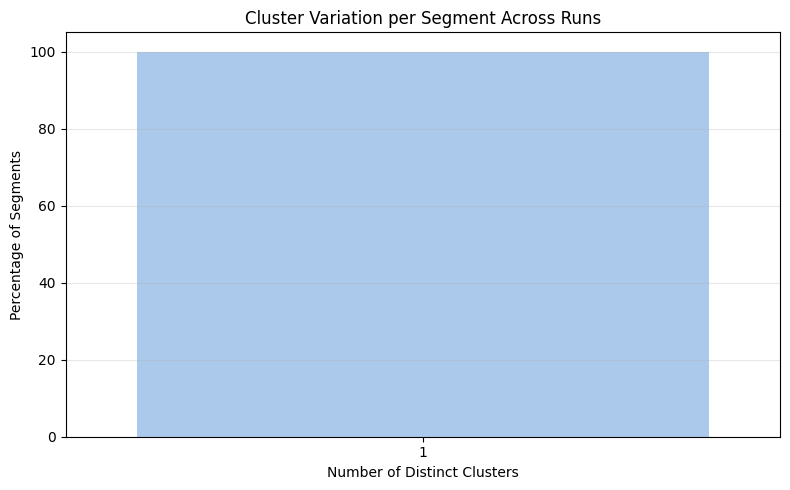

In [ ]:
df = pd.read_csv("segment_assignment_examples/aligned_assignments.csv")

# Estadística 1: Cuántos clusters distintos tiene cada segmento
df["unique_clusters"] = df[["run1", "run2", "run3", "run4", "run5"]].nunique(axis=1)
unique_counts = df["unique_clusters"].value_counts().sort_index()
total_segments = len(df)
unique_percentages = (unique_counts / total_segments * 100).round(2)

# Plot 1: Porcentaje de segmentos por número de clusters distintos
plt.figure(figsize=(8, 5))
sns.barplot(x=unique_percentages.index, y=unique_percentages.values, palette="pastel")
plt.title("Cluster Variation per Segment Across Runs")
plt.xlabel("Number of Distinct Clusters")
plt.ylabel("Percentage of Segments")
plt.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig("cluster_variation_barplot.png", dpi=300)
plt.show()

Interpretation: really good results as all segments belong to the same cluster in the 5 iterations.

Provides a table showing the segments that have been assigned to exactly two different clusters, along with the specific clusters involved.
This is done to identify potential patterns — for example, if many segments are consistently assigned to the same two clusters, this may indicate that those two clusters are very similar. In such cases, the clustering algorithm may struggle to distinguish between them, suggesting that the number of clusters k should be reduced.

In [ ]:
# Estadística 2: Para los segmentos con exactamente 2 clusters distintos
def two_cluster_pair(row):
    unique_vals = sorted(set(row))
    return tuple(unique_vals) if len(unique_vals) == 2 else None

df["two_cluster_pair"] = df[["run1", "run2", "run3", "run4", "run5"]].apply(two_cluster_pair, axis=1)
pair_counts = df["two_cluster_pair"].value_counts().dropna()

# Mostrar las combinaciones más frecuentes (si quieres)
print("\nPairs of clusters (if exactly two used):")
print(pair_counts)

# Convertir a DataFrame (porque value_counts devuelve una Series)
pair_counts_df = pair_counts.reset_index()
pair_counts_df.columns = ["Cluster_Pair", "Count"]

# Guardar como CSV
pair_counts_df.to_csv("two_cluster_pair_counts.csv", index=False)



Pairs of clusters (if exactly two used):
Series([], Name: count, dtype: int64)


Shows the distribution of segments across clusters.
To do this, it is assumed that if a segment is assigned to the same cluster in 4 out of 5 runs, then that segment belongs to that cluster.

<ipython-input-31-dbed7910dcf6>:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=majority_distribution.index, y=majority_distribution.values, palette="muted")


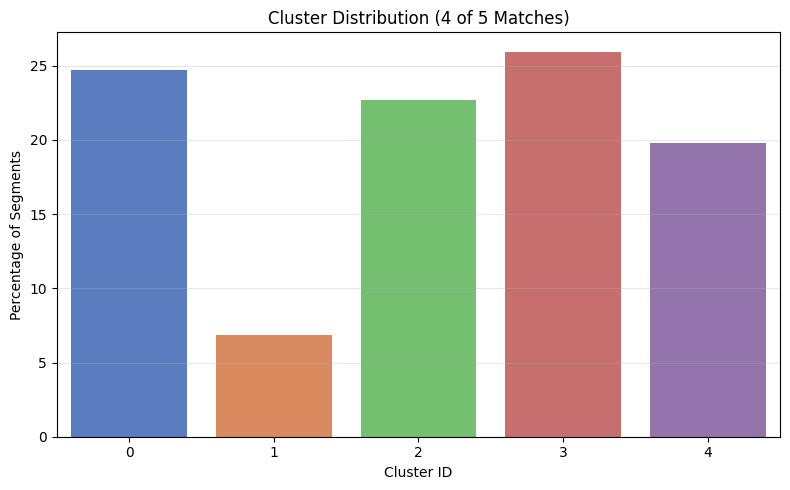

In [ ]:
# Estadística 3: Segmentos que coinciden en 4 de 5 ejecuciones
def most_common_if_4(row):
    counts = row.value_counts()
    if counts.max() >= 4:
        return counts.idxmax()
    else:
        return None

df["majority_cluster_4of5"] = df[["run1", "run2", "run3", "run4", "run5"]].apply(most_common_if_4, axis=1)
majority_distribution = df["majority_cluster_4of5"].value_counts(normalize=True).sort_index() * 100

# Plot 2: Distribución en 4 de 5 coincidencias
plt.figure(figsize=(8, 5))
sns.barplot(x=majority_distribution.index, y=majority_distribution.values, palette="muted")
plt.title("Cluster Distribution (4 of 5 Matches)")
plt.xlabel("Cluster ID")
plt.ylabel("Percentage of Segments")
plt.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig("majority_cluster_distribution.png")
plt.show()


Entropy per segment

What does it do?
It computes the entropy of the set of cluster assignments for each segment to measure the uncertainty in its classification.

Why is it relevant?
A consistent clustering should yield low entropy values, meaning that segments are always assigned to the same cluster. Entropy provides a continuous metric of individual segment stability across multiple runs.


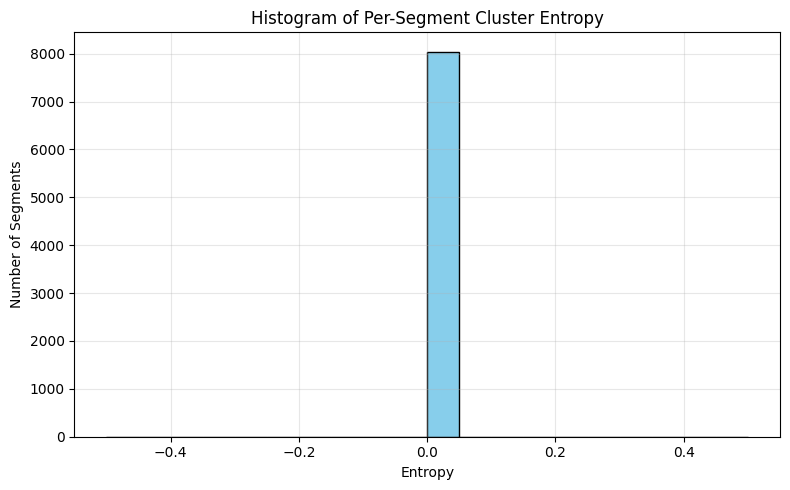

In [ ]:
# Crear carpeta
os.makedirs("plots", exist_ok=True)

# Cálculo de entropía
cluster_cols = ["run1", "run2", "run3", "run4", "run5"]
entropy_values = []

for _, row in aligned_assignments[cluster_cols].iterrows():
    counts = row.value_counts().values
    ent = entropy(counts, base=2)
    entropy_values.append(ent)

# Histograma
plt.figure(figsize=(8,5))
plt.hist(entropy_values, bins=20, color="skyblue", edgecolor="black")
plt.title("Histogram of Per-Segment Cluster Entropy")
plt.xlabel("Entropy")
plt.ylabel("Number of Segments")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("plots/entropy_histogram.png")
plt.show()
plt.close()

Interpretation:

Entropy = 0: the segment is always assigned to the same cluster → high stability.

High entropy (approximately 2.32 for five equally probable outcomes): the segment is randomly assigned to any cluster → very unstable.

Confusion matrix between runs (pairwise)

What does it do?
It generates a confusion matrix for each pair of runs (after alignment to run1), showing how many segments switch from one cluster to another.

Why is it relevant?
It allows identifying which clusters are most frequently confused. For example, if segments often switch between clusters 0 and 2, it may indicate that these clusters are not clearly distinguishable.

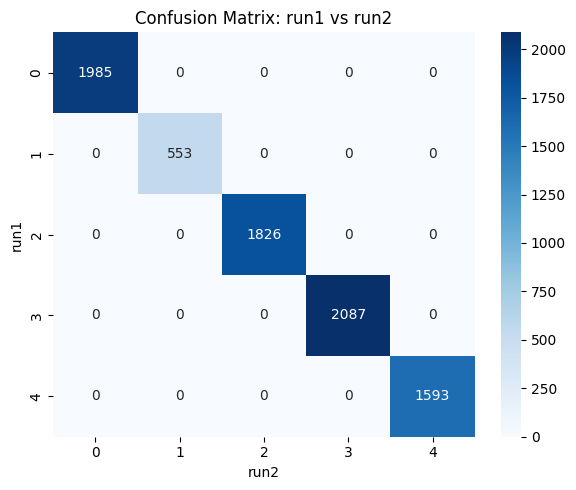

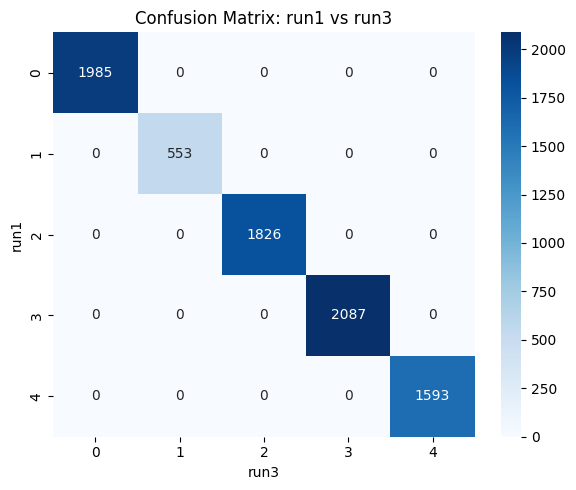

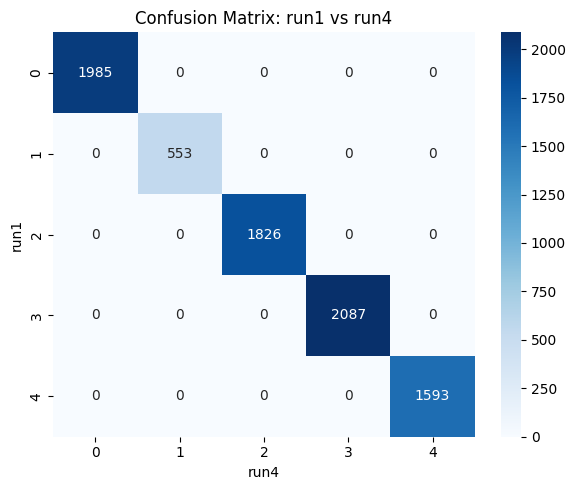

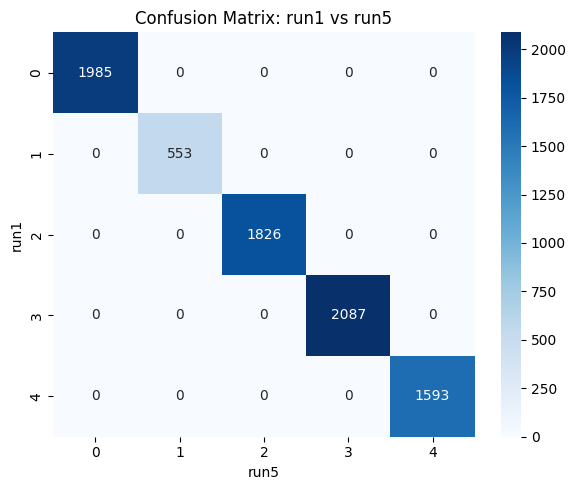

In [ ]:
# Comparación entre ejecuciones pares
for i in range(1, 5):
    runA = "run1"
    runB = f"run{i+1}"
    confusion = pd.crosstab(aligned_assignments[runA], aligned_assignments[runB])

    plt.figure(figsize=(6,5))
    sns.heatmap(confusion, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Confusion Matrix: run1 vs {runB}")
    plt.xlabel(runB)
    plt.ylabel("run1")
    plt.tight_layout()
    plt.savefig(f"plots/confusion_run1_vs_run{i+1}.png")
    plt.show()
    plt.close()


Interpretation:

High values on the diagonal: most segments are assigned to the same cluster in both runs → consistency.

High values off the diagonal: many segments switch clusters between runs → inconsistency.

The purpose of this is to obtain the result more compact and add it to the report.

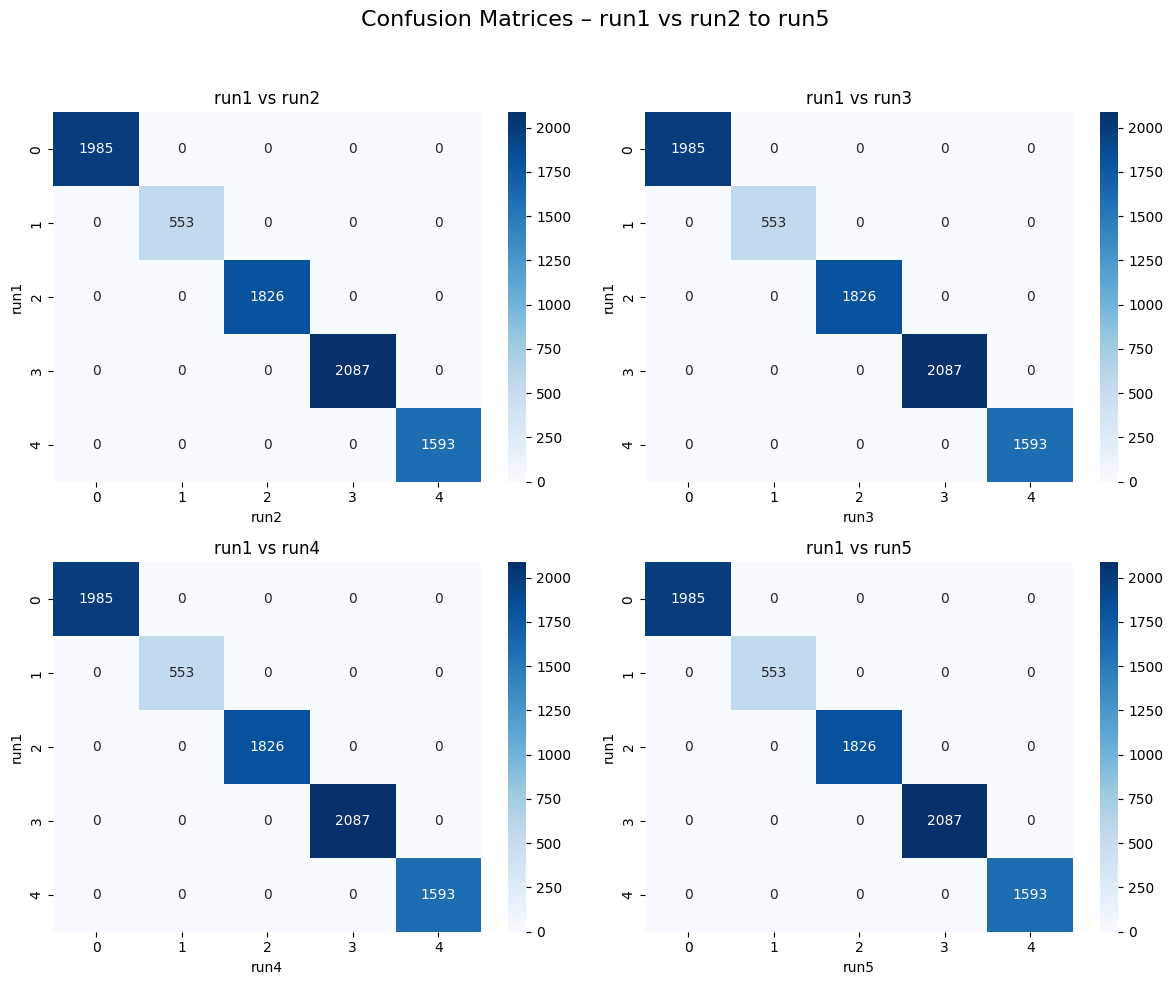

Figura guardada en: plots/confusion_matrices_all_runs.png


In [ ]:
# Preparar figura
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle("Confusion Matrices – run1 vs run2 to run5", fontsize=16)

for idx, i in enumerate(range(1, 5)):
    runA = "run1"
    runB = f"run{i+1}"
    confusion = pd.crosstab(aligned_assignments[runA], aligned_assignments[runB])

    ax = axes[idx // 2, idx % 2]  # Posiciona en subplot correspondiente
    sns.heatmap(confusion, annot=True, fmt="d", cmap="Blues", ax=ax)
    ax.set_title(f"{runA} vs {runB}")
    ax.set_xlabel(runB)
    ax.set_ylabel(runA)

plt.tight_layout(rect=[0, 0, 1, 0.95])
output_path = "plots/confusion_matrices_all_runs.png"
plt.savefig(output_path, dpi=300)
plt.show()

print(f"Figura guardada en: {output_path}")

MDS (or t-SNE) of average feature vectors per cluster

What does it do?
It reduces the dimensionality of the average feature vectors for each cluster in order to visualize the relative positions between clusters.

Why is it interesting?
It allows us to assess whether clusters are clearly separated or if some are too close to each other, which may suggest too many clusters have been chosen.

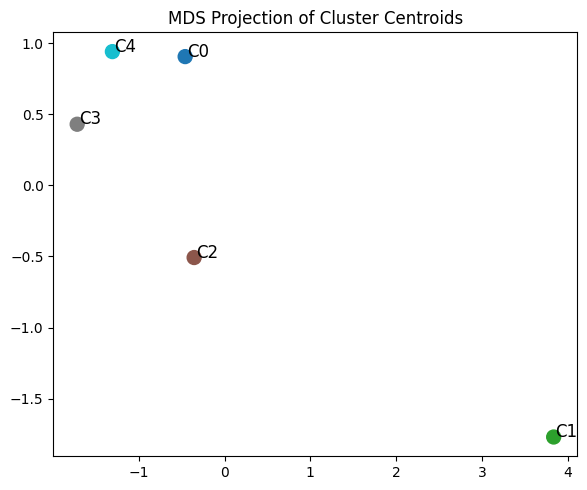

In [ ]:
# Agrupar vectores promedio por cluster (de run1)
cluster_avg = feature_tables[0].copy()
scaler = StandardScaler()
scaled_feats = scaler.fit_transform(cluster_avg)

# MDS
mds = MDS(n_components=2, random_state=42)
coords = mds.fit_transform(scaled_feats)

# Plot
plt.figure(figsize=(6,5))
plt.scatter(coords[:,0], coords[:,1], c=range(K), cmap="tab10", s=100)
for i, (x, y) in enumerate(coords):
    plt.text(x+0.02, y, f"C{i}", fontsize=12)

plt.title("MDS Projection of Cluster Centroids")
plt.tight_layout()
plt.savefig("plots/mds_clusters.png")
plt.show()
plt.close()


Interpretation:

Well-separated clusters: points are far apart → good morphological separation.

Close or overlapping clusters: they might be describing the same class → redundancy or overfitting.



What does it do?
It calculates how many segments have 5/5, 4/5, ..., 1/5 matching cluster assignments across runs for each value of K, and compares the results.

Why is it interesting?
It helps select the value of K that provides the highest clustering stability without requiring ground truth labels.



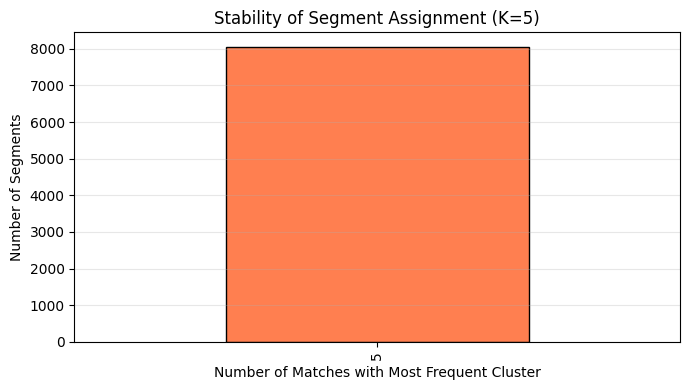

In [ ]:
def compute_stability_stats(aligned_df):
    counts = []
    for _, row in aligned_df[["run1", "run2", "run3", "run4", "run5"]].iterrows():
        most_common = row.mode()[0]
        count = (row == most_common).sum()
        counts.append(count)
    return pd.Series(counts).value_counts().sort_index()

# Simulación para K=5 (reemplaza por otras si tienes más)
stability_k5 = compute_stability_stats(aligned_assignments)

# Plot
plt.figure(figsize=(7,4))
stability_k5.plot(kind="bar", color="coral", edgecolor="black")
plt.title("Stability of Segment Assignment (K=5)")
plt.xlabel("Number of Matches with Most Frequent Cluster")
plt.ylabel("Number of Segments")
plt.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig("plots/stability_k5.png")
plt.show()
plt.close()


Interpretation:

5/5 matches: Maximum stability.

4/5 matches: Very high stability (likely noise in a single run).

≤3/5 matches: Low stability.


####Cluster Representation:

Now, for each cluster, we obtain 3 random plots and apply the characteristic point delineation algorithm.

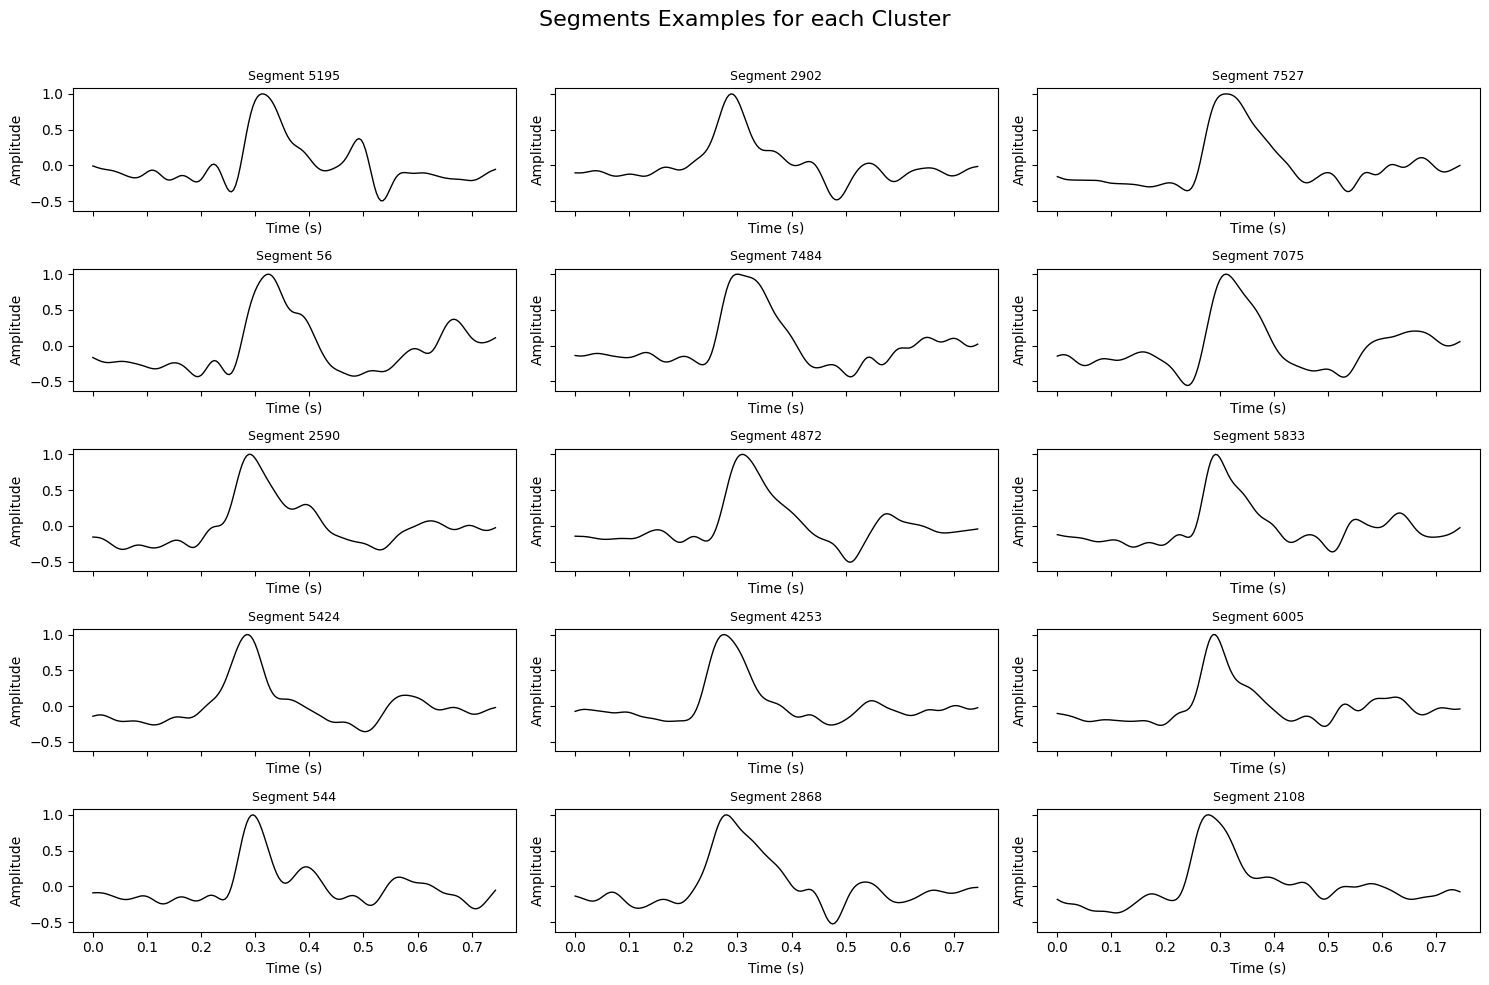

Gráfico guardado en: cluster_segment_plots/segment_examples_by_cluster.png


In [ ]:
# Paso 0: Leer el CSV y convertir las cadenas en arrays
valid_segments = pd.read_csv("valid_segments.csv")  # contiene 'icg_segment'
valid_segments['Segment'] = valid_segments['Segment'].apply(lambda s: np.fromstring(s.strip('[]'), sep=' '))
valid_segments['Segment'] = valid_segments['Segment'].apply(np.array)

# Guardar y volver a cargar en formato pickle
valid_segments.to_pickle("valid_segments.pkl")
valid_segments = pd.read_pickle("valid_segments.pkl")

# Cargar las asignaciones
aligned_assignments = pd.read_csv("segment_assignment_examples/aligned_assignments.csv")  # contiene 'Segment_ID' y 'run1' a 'run5'

# Paso 1: Determinar el cluster más frecuente por segmento
cluster_mode = aligned_assignments[['run1', 'run2', 'run3', 'run4', 'run5']].mode(axis=1)[0]
aligned_assignments['most_frequent_cluster'] = cluster_mode

# Paso 2: Elegir hasta 3 segmentos representativos por cluster
selected_segments = []
for cluster_id in range(5):
    segment_ids = aligned_assignments[aligned_assignments['most_frequent_cluster'] == cluster_id]['Segment_ID']
    sampled_ids = segment_ids.sample(n=min(3, len(segment_ids)))
    selected_segments.extend([(cluster_id, seg_id) for seg_id in sampled_ids])

# Paso 3: Crear la figura 5x3
fig, axes = plt.subplots(nrows=5, ncols=3, figsize=(15, 10), sharex=True, sharey=True)
fig.suptitle("Segments Examples for each Cluster", fontsize=16)


for (cluster_id, seg_id) in selected_segments:
    row = cluster_id
    row_segments = [s for s in selected_segments if s[0] == cluster_id]
    col = row_segments.index((cluster_id, seg_id))  # posición dentro del cluster
    ax = axes[row, col]
    segment_data = valid_segments.loc[seg_id, 'Segment']
    time_axis = np.arange(len(segment_data)) / FS
    ax.plot(time_axis, segment_data, color='black', linewidth='1')
    ax.set_title(f"Segment {seg_id}", fontsize=9)
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Amplitude")

plt.tight_layout(rect=[0, 0, 1, 0.97])

# Crear carpeta si no existe
os.makedirs("cluster_segment_plots", exist_ok=True)
output_path = "cluster_segment_plots/segment_examples_by_cluster.png"
plt.savefig(output_path)
plt.show()

print(f"Gráfico guardado en: {output_path}")


Applying the Characteristic Points Algorithm:

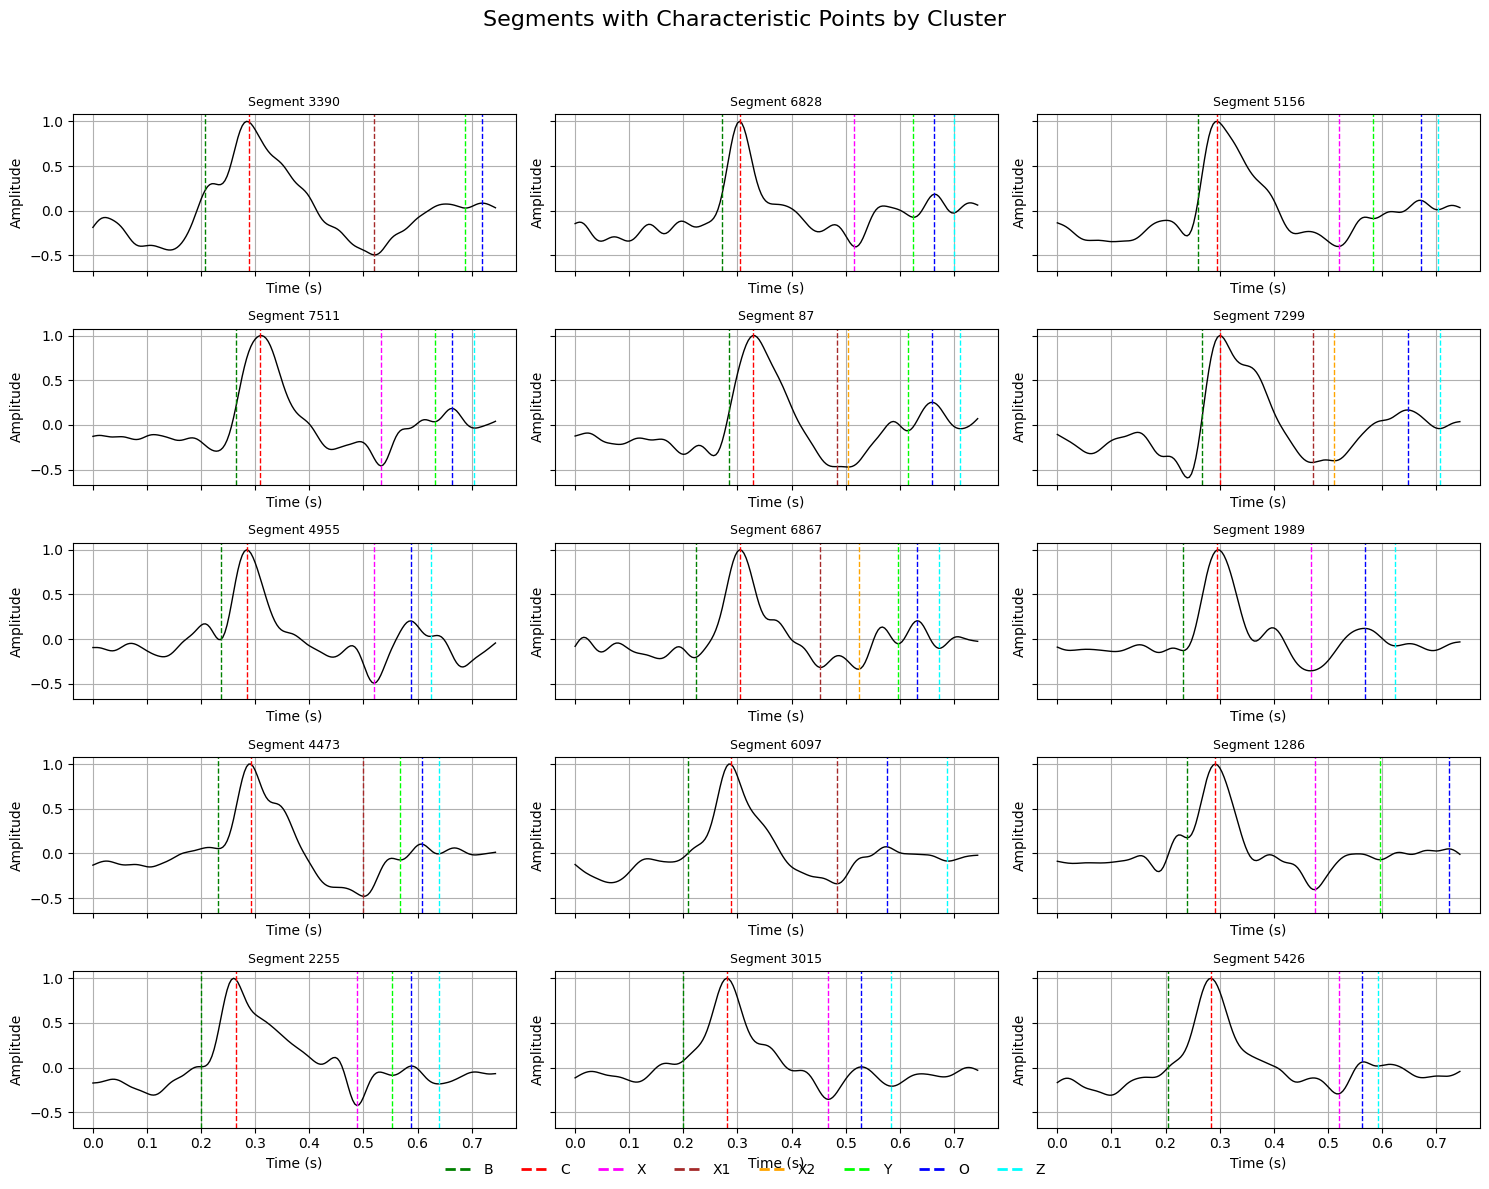

Gráfico guardado en: cluster_segment_plots/segment_examples_with_points.png


In [ ]:
fs = 250

# --- Tus funciones de delineación aquí ---
# Copia todas las funciones que me pasaste aquí (relative_energy, detect_C_peaks, find_B_point, detectar_punto_X, detect_O_point, detect_Z_point, detectar_punto_Y)
# Por brevedad no las repito, pero debes incluirlas exactamente como las tienes.

# --- Lectura de datos ---
valid_segments = pd.read_csv("valid_segments.csv")
valid_segments['Segment'] = valid_segments['Segment'].apply(lambda s: np.fromstring(s.strip('[]'), sep=' '))
valid_segments['Segment'] = valid_segments['Segment'].apply(np.array)

aligned_assignments = pd.read_csv("segment_assignment_examples/aligned_assignments.csv")

# Determinar cluster más frecuente
cluster_mode = aligned_assignments[['run1', 'run2', 'run3', 'run4', 'run5']].mode(axis=1)[0]
aligned_assignments['most_frequent_cluster'] = cluster_mode

# Elegir hasta 3 segmentos representativos por cluster
selected_segments = []
for cluster_id in range(5):
    segment_ids = aligned_assignments[aligned_assignments['most_frequent_cluster'] == cluster_id]['Segment_ID']
    sampled_ids = segment_ids.sample(n=min(3, len(segment_ids)), random_state=42)
    selected_segments.extend([(cluster_id, seg_id) for seg_id in sampled_ids])

# Crear figura 5x3
fig, axes = plt.subplots(nrows=5, ncols=3, figsize=(15, 12), sharex=True, sharey=True)
fig.suptitle("Segments with Characteristic Points by Cluster", fontsize=16)

for (cluster_id, seg_id) in selected_segments:
    row = cluster_id
    row_segments = [s for s in selected_segments if s[0] == cluster_id]
    col = row_segments.index((cluster_id, seg_id))
    ax = axes[row, col]

    segment_data = valid_segments.loc[seg_id, 'Segment']
    time_axis = np.arange(len(segment_data)) / fs

    # Plot señal en negro
    ax.plot(time_axis, segment_data, color='black', linewidth=1)

    # Delineación de puntos:
    C_peaks, _ = detect_C_peaks(segment_data, fs)
    if len(C_peaks) == 0:
        # Si no hay pico C, solo graficar señal
        ax.set_title(f"Segment {seg_id}", fontsize=9)
        continue

    C_idx = C_peaks[0]
    B_idx = find_B_point(segment_data, C_idx, fs)
    X_res = detectar_punto_X(segment_data, C_idx, fs)
    O_idx = detect_O_point(segment_data, C_idx, fs)
    Z_idx = detect_Z_point(segment_data, O_idx, fs) if O_idx is not None else None
    Y_idx = detectar_punto_Y(segment_data, X_res, O_idx, fs) if O_idx is not None else None

    # Función auxiliar para graficar línea discontinua vertical en un punto
    def plot_vline(ax, x_pos, y_data, color):
        if x_pos is not None and 0 <= x_pos < len(y_data):
            ax.axvline(x=x_pos/fs, color=color, linestyle='--', linewidth=1)

    # Graficar líneas discontinuas en cada punto característico
    plot_vline(ax, B_idx, segment_data, 'green')
    plot_vline(ax, C_idx, segment_data, 'red')

    if X_res['caso'] == 'X':
        plot_vline(ax, X_res['X'], segment_data, 'magenta')
    elif X_res['caso'] == 'X1':
        plot_vline(ax, X_res['X1'], segment_data, 'brown')
    elif X_res['caso'] == 'X1_X2':
        plot_vline(ax, X_res['X1'], segment_data, 'brown')
        plot_vline(ax, X_res['X2'], segment_data, 'orange')

    plot_vline(ax, O_idx, segment_data, 'blue')
    plot_vline(ax, Z_idx, segment_data, 'cyan')
    plot_vline(ax, Y_idx, segment_data, 'lime')

    ax.set_title(f"Segment {seg_id}", fontsize=9)
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Amplitude")
    ax.grid(True)

plt.tight_layout(rect=[0, 0, 1, 0.95])

legend_lines = [
    Line2D([0], [0], color='green', linestyle='--', lw=2, label='B'),
    Line2D([0], [0], color='red', linestyle='--', lw=2, label='C'),
    Line2D([0], [0], color='magenta', linestyle='--', lw=2, label='X'),
    Line2D([0], [0], color='brown', linestyle='--', lw=2, label='X1'),
    Line2D([0], [0], color='orange', linestyle='--', lw=2, label='X2'),
    Line2D([0], [0], color='lime', linestyle='--', lw=2, label='Y'),
    Line2D([0], [0], color='blue', linestyle='--', lw=2, label='O'),
    Line2D([0], [0], color='cyan', linestyle='--', lw=2, label='Z'),
]

fig.legend(handles=legend_lines, loc='lower center', ncol=9, fontsize=10, frameon=False)

# Save and show
os.makedirs("cluster_segment_plots", exist_ok=True)
output_path = "cluster_segment_plots/segment_examples_with_points.png"
plt.savefig(output_path)
plt.show()

print(f"Gráfico guardado en: {output_path}")


This figure is created as a summary for the project report. It includes for each resulting cluster, all segments and the medoid in black.

Medoids calculados para cada cluster.


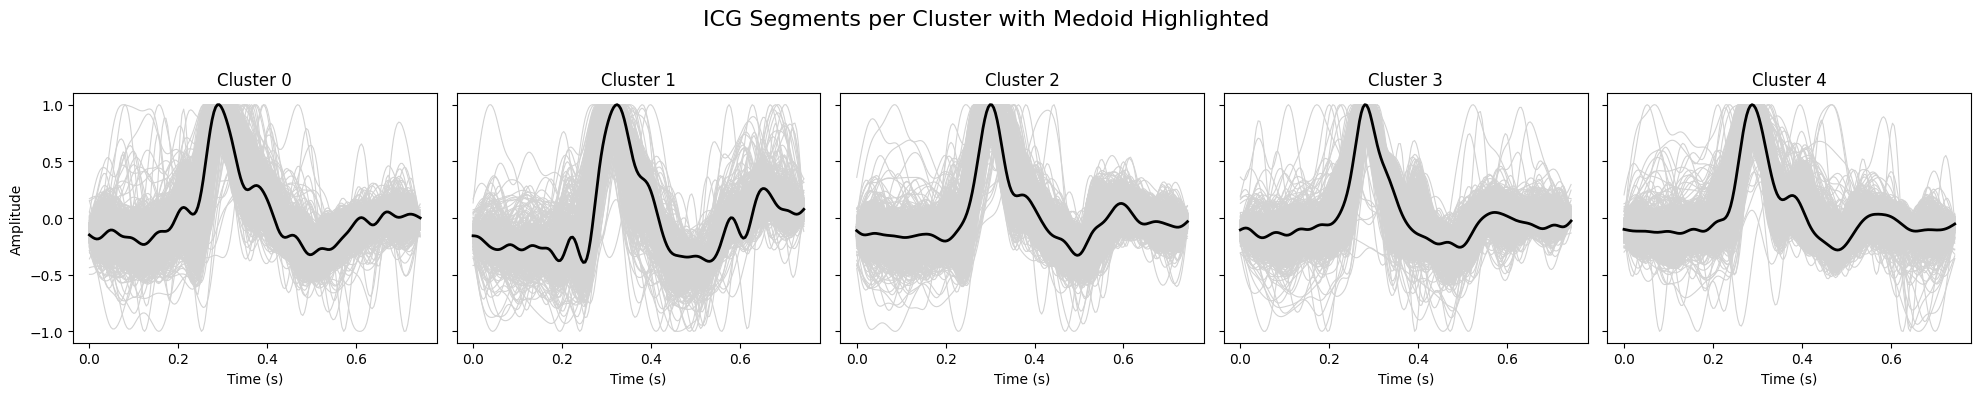

Gráfico guardado en: cluster_segment_plots/all_segments_with_medoid.png


In [ ]:
FS = 250  # frecuencia de muestreo, ajusta si hace falta

# Cargar CSV con segmentos y clusters definitivos
df = pd.read_csv("segment_assignment_examples/aligned_assignments.csv")

# Convertir la columna 'icg_segment' a arrays NumPy
df['Segment'] = df['Segment'].apply(lambda s: np.fromstring(s.strip('[]'), sep=' '))

# Inicializamos lista para almacenar los medoids
medoids = []

# Para cada cluster, calcular el medoid
for cluster_id in range(5):
    cluster_segs = df[df['definitive_cluster'] == cluster_id]['Segment'].tolist()
    # Convertir lista de arrays a matriz 2D (segmentos x muestras)
    data = np.vstack(cluster_segs)  # shape (n_segmentos, n_muestras)

    # Calcular matriz de distancias euclidianas
    dist_matrix = cdist(data, data, metric='euclidean')

    # Sumar distancias por fila y obtener índice del mínimo
    medoid_idx = np.argmin(dist_matrix.sum(axis=1))

    # Guardar el segmento medoid
    medoids.append(data[medoid_idx])

print("Medoids calculados para cada cluster.")

# Ahora plotear
fig, axes = plt.subplots(1, 5, figsize=(20, 4), sharex=True, sharey=True)
fig.suptitle("ICG Segments per Cluster with Medoid Highlighted", fontsize=16)

for cluster_id in range(5):
    ax = axes[cluster_id]

    cluster_segments = df[df['definitive_cluster'] == cluster_id]['Segment']

    # Plotear todos en gris claro
    for segment in cluster_segments:
        time_axis = np.arange(len(segment)) / FS
        ax.plot(time_axis, segment, color='lightgray', linewidth=0.8)

    # Plotear medoid en negro
    medoid = medoids[cluster_id]
    time_axis = np.arange(len(medoid)) / FS
    ax.plot(time_axis, medoid, color='black', linewidth=2)

    ax.set_title(f"Cluster {cluster_id}", fontsize=12)
    ax.set_xlabel("Time (s)")
    if cluster_id == 0:
        ax.set_ylabel("Amplitude")

plt.tight_layout(rect=[0, 0, 1, 0.95])

# Guardar figura
os.makedirs("cluster_segment_plots", exist_ok=True)
output_path = "cluster_segment_plots/all_segments_with_medoid.png"
plt.savefig(output_path, dpi=300)
plt.show()

print(f"Gráfico guardado en: {output_path}")
